# 04 — Geometry Optimization: Finding Energy Minima

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ppt-2/Ch121a-DFT/blob/main/notebooks/04_geometry_optimization.ipynb)

## 🎯 Learning Objectives

- Potential energy surfaces (PES)
- PySCF with geomeTRIC to optimize molecular geometries
- Convergence criteria and common pitfalls in geometry optimization
- Some ORCA input files for geometry optimization
- How does the method/basis affects optimized geometries?

## Theory: Potential Energy Surfaces and Optimization

### 4.1 The Born-Oppenheimer Potential Energy Surface

Within the Born-Oppenheimer approximation, electrons adjust instantaneously to
nuclear motion. The electronic energy as a function of nuclear coordinates
$\mathbf{R} = \{R_I\}$ defines the **potential energy surface (PES)**:

$$E_{BO}(\mathbf{R}) = \langle \Psi_{elec} | \hat{H}_{elec} | \Psi_{elec} \rangle$$

**Stationary points** on the PES satisfy:
$$\mathbf{g}(\mathbf{R}) = \frac{\partial E}{\partial \mathbf{R}} = \mathbf{0}$$

- **Minimum**: all eigenvalues of the Hessian matrix $\mathbf{H} = \frac{\partial^2 E}{\partial R_i \partial R_j}$ are positive
- **Transition state (TS)**: exactly one negative Hessian eigenvalue (imaginary frequency)
- **Higher-order saddle point**: two or more negative eigenvalues

### 4.2 Gradient-Based Optimization Algorithms

Modern geometry optimizers compute the energy gradient $\mathbf{g}$ analytically
and use it to step toward the minimum:

**Steepest Descent**: $\mathbf{R}_{n+1} = \mathbf{R}_n - \alpha \mathbf{g}_n$
(simple but slow convergence)

**Quasi-Newton (BFGS/L-BFGS)**:
$$\mathbf{R}_{n+1} = \mathbf{R}_n - \mathbf{H}_n^{-1} \mathbf{g}_n$$
where the approximate inverse Hessian $\mathbf{H}_n^{-1}$ is updated at each step.
This is the algorithm used in most QC codes (e.g., geomeTRIC, DL-FIND, Berny).

**RFO (Rational Function Optimization)**: Finds both minima and transition states
by solving a modified Newton equation with level-shift parameter.

### 4.3 Convergence Criteria

A geometry optimization is typically considered converged when ALL of these are satisfied:

| Criterion | Tight threshold | Default threshold |
|-----------|:--------------:|:-----------------:|
| Max gradient component | $< 1.5 \times 10^{-5}$ Ha/Å | $< 4.5 \times 10^{-4}$ Ha/Å |
| RMS gradient | $< 1.0 \times 10^{-5}$ Ha/Å | $< 3.0 \times 10^{-4}$ Ha/Å |
| Max displacement | $< 6.0 \times 10^{-5}$ Å | $< 1.8 \times 10^{-3}$ Å |
| RMS displacement | $< 4.0 \times 10^{-5}$ Å | $< 1.2 \times 10^{-3}$ Å |


**Some codes also use Bohr as the unit, 1 Bohr = 0.529177 Å**

**For energy unit conversion, helpful table, https://wild.life.nctu.edu.tw/class/common/energy-unit-conv-table-detail.html**
### 4.4 Internal vs Cartesian Coordinates

Cartesian coordinates: $3N$ degrees of freedom (including 6 translations/rotations)
Internal coordinates (Z-matrix): bond lengths, bond angles, dihedral angles
**Delocalized internal coordinates** (geomeTRIC): linear combinations of primitive
internals \u2014 generally the fastest convergence.

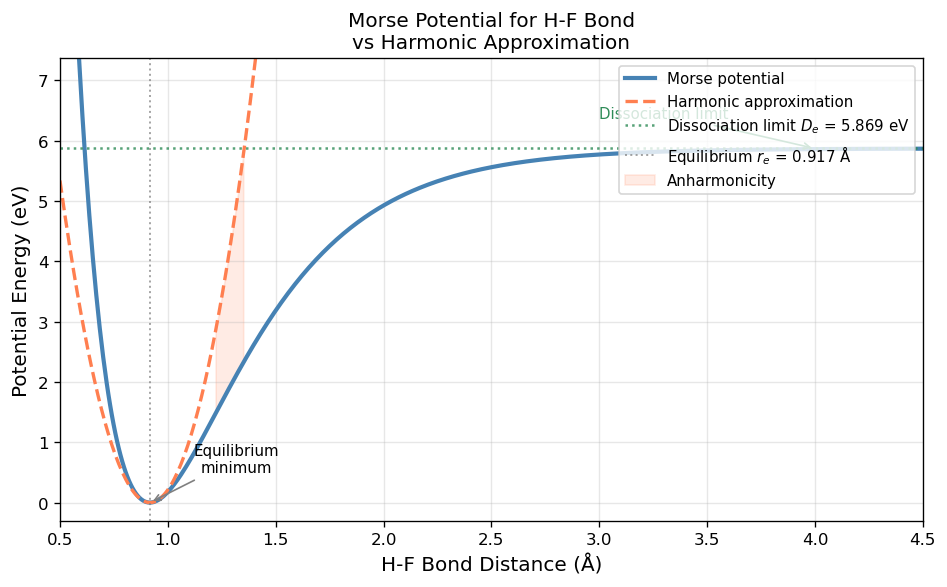

H-F bond parameters:
  Equilibrium distance r_e = 0.917 Å
  Dissociation energy  D_e = 5.869 eV = 135.3 kcal/mol
  Force constant       k   = 61.39 eV/Å² = 984 N/m


In [1]:
# =============================================================================
# Ch121a: Quantum Chemistry & DFT — Notebook 04: Geometry Optimization
# License: GPL-3.0 (https://www.gnu.org/licenses/gpl-3.0.en.html)
# =============================================================================
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyscf import gto, dft, scf

# ------------------------------------------------------------------
# Morse Potential: Realistic Bond Potential Energy Surface
# ------------------------------------------------------------------
# The Morse potential is a good approximation to a diatomic bond:
#   V(r) = D_e * [1 - exp(-α(r - r_e))]^2
#
# Parameters for H-F bond:
De = 5.869    # eV — dissociation energy from minimum
alpha = 2.287 # Å^-1
r_e = 0.917   # Å — equilibrium bond length

r = np.linspace(0.5, 4.5, 500)  # Angstrom

# Morse potential
V_morse = De * (1 - np.exp(-alpha * (r - r_e)))**2

# Harmonic approximation: V = (1/2) k (r - r_e)^2
# Force constant k = 2 * D_e * alpha^2 (eV/Å^2)
k = 2 * De * alpha**2
V_harmonic = 0.5 * k * (r - r_e)**2

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(r, V_morse, '-', color='steelblue', linewidth=2.5, label='Morse potential')
ax.plot(r, V_harmonic, '--', color='coral', linewidth=2, label='Harmonic approximation')
ax.axhline(y=De, color='seagreen', linestyle=':', linewidth=1.5, alpha=0.8,
           label=f'Dissociation limit $D_e$ = {De:.3f} eV')
ax.axvline(x=r_e, color='gray', linestyle=':', linewidth=1.2, alpha=0.7,
           label=f'Equilibrium $r_e$ = {r_e:.3f} Å')

# Annotate
ax.annotate('Equilibrium\nminimum', xy=(r_e, 0), xytext=(r_e+0.4, 0.5),
            arrowprops=dict(arrowstyle='->', color='gray'),
            fontsize=9, ha='center')
ax.annotate('Dissociation limit', xy=(4.0, De), xytext=(3.0, De+0.5),
            arrowprops=dict(arrowstyle='->', color='seagreen'),
            fontsize=9, color='seagreen')

# Shade anharmonic region
ax.fill_between(r, V_harmonic, V_morse,
                where=(r > r_e + 0.3) & (V_harmonic < De),
                alpha=0.15, color='coral', label='Anharmonicity')

ax.set_xlim(0.5, 4.5)
ax.set_ylim(-0.3, De + 1.5)
ax.set_xlabel('H-F Bond Distance (Å)', fontsize=12)
ax.set_ylabel('Potential Energy (eV)', fontsize=12)
ax.set_title('Morse Potential for H-F Bond\nvs Harmonic Approximation', fontsize=12)
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'H-F bond parameters:')
print(f'  Equilibrium distance r_e = {r_e:.3f} Å')
print(f'  Dissociation energy  D_e = {De:.3f} eV = {De*23.06:.1f} kcal/mol')
print(f'  Force constant       k   = {k:.2f} eV/Å² = {k*1.6022e-19/1e-20:.0f} N/m')

In [2]:
%%time
# ------------------------------------------------------------------
# Geometry Optimization of Water: B3LYP/def2-SVP
# ------------------------------------------------------------------
# We use PySCF's geometric_solver (geomeTRIC optimizer)
# Starting from a slightly distorted geometry to test convergence.

from pyscf import gto, dft
from pyscf.geomopt import geometric_solver
import numpy as np
from pyscf.data.nist import BOHR  # Bohr to Angstrom conversion

# Slightly distorted initial geometry
mol = gto.Mole()
mol.atom = '''
O   0.000000   0.000000   0.100000
H   0.000000   0.800000  -0.400000
H   0.000000  -0.800000  -0.400000
'''
mol.basis = 'def2-SVP'
mol.verbose = 0
mol.build()

mf = dft.RKS(mol)
mf.xc = 'B3LYP'
mf.verbose = 0

print('Starting geometry (distorted):')
print(f"  {'Atom':5s}  {'x (Å)':>10s}  {'y (Å)':>10s}  {'z (Å)':>10s}")
for i in range(mol.natm):
    sym = mol.atom_symbol(i)
    coords = mol.atom_coord(i) * BOHR  # Convert from Bohr to Angstrom
    print(f"  {sym:5s}  {coords[0]:10.6f}  {coords[1]:10.6f}  {coords[2]:10.6f}")

# Run geometry optimization
conv_mol = geometric_solver.optimize(mf, verbose=0)

print('\nOptimized geometry (B3LYP/def2-SVP):')
print(f"  {'Atom':5s}  {'x (Å)':>10s}  {'y (Å)':>10s}  {'z (Å)':>10s}")
final_coords = []
for i in range(conv_mol.natm):
    sym = conv_mol.atom_symbol(i)
    coords = conv_mol.atom_coord(i) * BOHR
    final_coords.append(coords)
    print(f"  {sym:5s}  {coords[0]:10.6f}  {coords[1]:10.6f}  {coords[2]:10.6f}")

# Compute bond lengths and angle
O_pos = final_coords[0]
H1_pos = final_coords[1]
H2_pos = final_coords[2]

r_OH1 = np.linalg.norm(H1_pos - O_pos)
r_OH2 = np.linalg.norm(H2_pos - O_pos)
# Bond angle
v1 = H1_pos - O_pos
v2 = H2_pos - O_pos
cos_angle = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
angle = np.degrees(np.arccos(cos_angle))

print(f'\nOptimized structural parameters:')
print(f'  r(O-H₁) = {r_OH1:.4f} Å  (exp: 0.9572 Å)')
print(f'  r(O-H₂) = {r_OH2:.4f} Å  (exp: 0.9572 Å)')
print(f'  ∠(H-O-H) = {angle:.2f}°  (exp: 104.52°)')
print(f'\n  Error r(OH): {abs(r_OH1-0.9572)*1000:.1f} mÅ')
print(f'  Error angle: {abs(angle-104.52):.2f}°')

geometric-optimize called with the following command line:
/resnick/groups/wag/prabhat/programs/miniconda3/envs/poscar_vis/lib/python3.10/site-packages/ipykernel_launcher.py -f /resnick/home/pprakash/.local/share/jupyter/runtime/kernel-0e2d47e7-233f-467b-99a0-2bef0c620a63.json

                                        ())))))))))))))))/                     
                                    ())))))))))))))))))))))))),                
                                *)))))))))))))))))))))))))))))))))             
                        #,    ()))))))))/                .)))))))))),          
                      #%%%%,  ())))))                        .))))))))*        
                      *%%%%%%,  ))              ..              ,))))))).      
                        *%%%%%%,         ***************/.        .)))))))     
                #%%/      (%%%%%%,    /*********************.       )))))))    
              .%%%%%%#      *%%%%%%,  *******/,     **********,      .))))))   
 

Starting geometry (distorted):
  Atom        x (Å)       y (Å)       z (Å)
  O        0.000000    0.000000    0.100000
  H        0.000000    0.800000   -0.400000
  H        0.000000   -0.800000   -0.400000


Step    0 : Gradient = 3.370e-02/4.700e-02 (rms/max) Energy = -76.3540908208
Hessian Eigenvalues: 5.00000e-02 5.00000e-02 5.00000e-02 ... 1.60000e-01 5.92032e-01 5.92032e-01
Step    1 : Displace = 4.766e-02/5.350e-02 (rms/max) Trust = 1.000e-01 (=) Grad = 8.896e-03/1.225e-02 (rms/max) E (change) = -76.3581064646 (-4.016e-03) Quality = 1.257
Hessian Eigenvalues: 5.00000e-02 5.00000e-02 5.00000e-02 ... 1.31681e-01 5.54716e-01 5.92032e-01
Step    2 : Displace = 1.342e-02/1.541e-02 (rms/max) Trust = 1.414e-01 (+) Grad = 6.565e-04/7.815e-04 (rms/max) E (change) = -76.3583120761 (-2.056e-04) Quality = 0.915
Hessian Eigenvalues: 4.99996e-02 5.00000e-02 5.00000e-02 ... 1.52911e-01 5.20769e-01 5.92032e-01
Step    3 : Displace = 2.135e-03/2.385e-03 (rms/max) Trust = 2.000e-01 (+) Grad = 4.143e-05/4.998e-05 (rms/max) E (change) = -76.3583157444 (-3.668e-06) Quality = 0.949
Hessian Eigenvalues: 4.99842e-02 5.00000e-02 5.00000e-02 ... 1.57602e-01 5.30440e-01 5.92032e-01
Step    4 : Displace = 9.837


Optimized geometry (B3LYP/def2-SVP):
  Atom        x (Å)       y (Å)       z (Å)
  O       -0.000000   -0.000000    0.167195
  H       -0.000000    0.757035   -0.433979
  H       -0.000000   -0.757035   -0.433979

Optimized structural parameters:
  r(O-H₁) = 0.9667 Å  (exp: 0.9572 Å)
  r(O-H₂) = 0.9667 Å  (exp: 0.9572 Å)
  ∠(H-O-H) = 103.09°  (exp: 104.52°)

  Error r(OH): 9.5 mÅ
  Error angle: 1.43°
CPU times: user 25.3 s, sys: 204 ms, total: 25.5 s
Wall time: 8.51 s


In [3]:
%%time
# ------------------------------------------------------------------
# Systematic Comparison: B3LYP/def2-SVP vs Experiment
# ------------------------------------------------------------------

from pyscf import gto, dft
from pyscf.geomopt import geometric_solver
from pyscf.data.nist import BOHR
import numpy as np
import pandas as pd

# Experimental reference data
# Format: name, atom_str, bond_label, bond_idx_pair, exp_value (Å), angle_label, angle_idx, exp_angle (deg)
molecules = [
    {
        'name': 'H₂O',
        'atom': 'O 0 0 0.117; H 0 0.757 -0.469; H 0 -0.757 -0.469',
        'bond_pair': (0, 1),
        'bond_label': 'r(O-H)',
        'exp_bond': 0.9572,
        'angle_triplet': (1, 0, 2),
        'angle_label': '∠(H-O-H)',
        'exp_angle': 104.52,
    },
    {
        'name': 'HF',
        'atom': 'H 0 0 0; F 0 0 0.917',
        'bond_pair': (0, 1),
        'bond_label': 'r(H-F)',
        'exp_bond': 0.9168,
        'angle_triplet': None,
        'angle_label': None,
        'exp_angle': None,
    },
    {
        'name': 'CO',
        'atom': 'C 0 0 0; O 0 0 1.128',
        'bond_pair': (0, 1),
        'bond_label': 'r(C-O)',
        'exp_bond': 1.1283,
        'angle_triplet': None,
        'angle_label': None,
        'exp_angle': None,
    },
    {
        'name': 'NH₃',
        'atom': 'N 0 0 0.116; H 0 0.939 -0.269; H 0.814 -0.469 -0.269; H -0.814 -0.469 -0.269',
        'bond_pair': (0, 1),
        'bond_label': 'r(N-H)',
        'exp_bond': 1.012,
        'angle_triplet': (1, 0, 2),
        'angle_label': '∠(H-N-H)',
        'exp_angle': 106.67,
    },
]

results = []
for mol_data in molecules:
    mol = gto.Mole()
    mol.atom = mol_data['atom']
    mol.basis = 'def2-SVP'
    mol.verbose = 0
    mol.build()
    
    mf = dft.RKS(mol)
    mf.xc = 'B3LYP'
    mf.verbose = 0
    
    conv_mol = geometric_solver.optimize(mf, verbose=0)
    
    coords = np.array([conv_mol.atom_coord(i) * BOHR for i in range(conv_mol.natm)])
    i, j = mol_data['bond_pair']
    bond_len = np.linalg.norm(coords[j] - coords[i])
    
    row = {
        'Molecule': mol_data['name'],
        'Parameter': mol_data['bond_label'],
        'Computed (Å)': round(bond_len, 4),
        'Experiment (Å)': mol_data['exp_bond'],
        'Error (mÅ)': round((bond_len - mol_data['exp_bond'])*1000, 1),
    }
    
    if mol_data['angle_triplet']:
        a, b, c = mol_data['angle_triplet']
        v1 = coords[a] - coords[b]
        v2 = coords[c] - coords[b]
        cos_a = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2))
        angle = np.degrees(np.arccos(np.clip(cos_a, -1, 1)))
        row['Angle Param'] = mol_data['angle_label']
        row['Computed (°)'] = round(angle, 2)
        row['Exp (°)'] = mol_data['exp_angle']
    else:
        row['Angle Param'] = '—'
        row['Computed (°)'] = '—'
        row['Exp (°)'] = '—'
    
    results.append(row)
    print(f"  {mol_data['name']:5s}: {mol_data['bond_label']} = {bond_len:.4f} Å  "
          f"(exp: {mol_data['exp_bond']:.4f} Å, Δ = {(bond_len-mol_data['exp_bond'])*1000:.1f} mÅ)")

df_geom = pd.DataFrame(results)
print('\n')
print('Geometry Comparison: B3LYP/def2-SVP vs Experiment')
print(df_geom[['Molecule','Parameter','Computed (Å)','Experiment (Å)','Error (mÅ)']].to_string(index=False))
mae_bond = np.mean(np.abs([r['Error (mÅ)'] for r in results]))
print(f'\nMean absolute error in bond lengths: {mae_bond:.1f} mÅ')

geometric-optimize called with the following command line:
/resnick/groups/wag/prabhat/programs/miniconda3/envs/poscar_vis/lib/python3.10/site-packages/ipykernel_launcher.py -f /resnick/home/pprakash/.local/share/jupyter/runtime/kernel-0e2d47e7-233f-467b-99a0-2bef0c620a63.json

                                        ())))))))))))))))/                     
                                    ())))))))))))))))))))))))),                
                                *)))))))))))))))))))))))))))))))))             
                        #,    ()))))))))/                .)))))))))),          
                      #%%%%,  ())))))                        .))))))))*        
                      *%%%%%%,  ))              ..              ,))))))).      
                        *%%%%%%,         ***************/.        .)))))))     
                #%%/      (%%%%%%,    /*********************.       )))))))    
              .%%%%%%#      *%%%%%%,  *******/,     **********,      .))))))   
 

  H₂O  : r(O-H) = 0.9667 Å  (exp: 0.9572 Å, Δ = 9.5 mÅ)



-=#  geomeTRIC started. Version: 1.1  #=-
Current date and time: 2026-04-06 01:54:31
#========================================================#
#|     Arguments passed to driver run_optimizer():      |#
#========================================================#
customengine              <pyscf.geomopt.geometric_solver.PySCFEngine object at 0x7f49111d1840> 
input                     /tmp/tmppxpxcywq/7e55d7f1-edf8-4547-82c5-e9599489bfdb 
logIni                    /resnick/groups/wag/prabhat/programs/miniconda3/envs/poscar_vis/lib/python3.10/site-packages/pyscf/geomopt/log.ini 
maxiter                   100 
verbose                   0 
----------------------------------------------------------
Custom engine selected.
Bonds will be generated from interatomic distances less than 1.20 times sum of covalent radii
6 internal coordinates being used (instead of 6 Cartesians)
Internal coordinate system (atoms numbered from 1):
Distance 1-2
Translation-X 1-2
Translation-Y 1-2
Translation-Z 1-2
R

  HF   : r(H-F) = 0.9248 Å  (exp: 0.9168 Å, Δ = 8.0 mÅ)


Step    0 : Gradient = 5.964e-03/5.969e-03 (rms/max) Energy = -113.2249989177
Hessian Eigenvalues: 5.00000e-02 5.00000e-02 5.00000e-02 ... 5.00000e-02 5.00000e-02 1.51249e+00
Step    1 : Displace = 1.043e-03/1.043e-03 (rms/max) Trust = 1.000e-01 (=) Grad = 7.599e-04/7.647e-04 (rms/max) E (change) = -113.2250121128 (-1.320e-05) Quality = 1.122
Hessian Eigenvalues: 4.99914e-02 5.00000e-02 5.00000e-02 ... 5.00000e-02 5.00000e-02 1.31991e+00
Step    2 : Displace = 1.524e-04/1.524e-04 (rms/max) Trust = 1.414e-01 (+) Grad = 8.048e-06/1.129e-05 (rms/max) E (change) = -113.2250123281 (-2.152e-07) Quality = 0.978
Hessian Eigenvalues: 4.99914e-02 5.00000e-02 5.00000e-02 ... 5.00000e-02 5.00000e-02 1.31991e+00
Converged! =D

    #==========================================================================#
    #| If this code has benefited your research, please support us by citing: |#
    #|                                                                        |#
    #| Wang, L.-P.; Song, C.C. (2

  CO   : r(C-O) = 1.1304 Å  (exp: 1.1283 Å, Δ = 2.1 mÅ)


Step    0 : Gradient = 6.183e-03/8.636e-03 (rms/max) Energy = -56.5093022841
Hessian Eigenvalues: 5.00000e-02 5.00000e-02 5.00000e-02 ... 4.51006e-01 4.51006e-01 4.51679e-01
Step    1 : Displace = 5.393e-03/9.081e-03 (rms/max) Trust = 1.000e-01 (=) Grad = 1.593e-03/2.715e-03 (rms/max) E (change) = -56.5094494938 (-1.472e-04) Quality = 1.273
Hessian Eigenvalues: 4.99999e-02 5.00000e-02 5.00000e-02 ... 4.50934e-01 4.51006e-01 4.80263e-01
Step    2 : Displace = 5.081e-03/7.853e-03 (rms/max) Trust = 1.414e-01 (+) Grad = 8.300e-05/1.086e-04 (rms/max) E (change) = -56.5094752534 (-2.576e-05) Quality = 1.046
Hessian Eigenvalues: 4.99991e-02 5.00000e-02 5.00000e-02 ... 4.50983e-01 4.51006e-01 4.86029e-01
Step    3 : Displace = 3.513e-04/4.290e-04 (rms/max) Trust = 2.000e-01 (+) Grad = 8.626e-06/9.221e-06 (rms/max) E (change) = -56.5094753530 (-9.957e-08) Quality = 1.003
Hessian Eigenvalues: 4.99991e-02 5.00000e-02 5.00000e-02 ... 4.50983e-01 4.51006e-01 4.86029e-01
Converged! =D

    #========

  NH₃  : r(N-H) = 1.0226 Å  (exp: 1.0120 Å, Δ = 10.6 mÅ)


Geometry Comparison: B3LYP/def2-SVP vs Experiment
Molecule Parameter  Computed (Å)  Experiment (Å)  Error (mÅ)
     H₂O    r(O-H)        0.9667          0.9572         9.5
      HF    r(H-F)        0.9248          0.9168         8.0
      CO    r(C-O)        1.1304          1.1283         2.1
     NH₃    r(N-H)        1.0226          1.0120        10.6

Mean absolute error in bond lengths: 7.6 mÅ
CPU times: user 1min 12s, sys: 379 ms, total: 1min 13s
Wall time: 19.6 s


## 4.X. ORCA Geometry Optimization Input

The same B3LYP/def2-SVP geometry optimization in ORCA:
Copy as test_orca.inp, in preferred directory, while also taking script.sh from ../Initialization 
```
# ORCA geometry optimization of water
# Method: B3LYP-D3(BJ)/def2-SVP
! B3LYP-D3BJ def2-SVP def2/J RIJCOSX Opt

%pal
  nprocs 4    # Number of parallel cores
end

%geom
  MaxIter  100         # Maximum optimization steps
  Convergence tight    # Tight convergence criteria
  MaxStep  0.3         # Maximum step size in internal coordinates
end

* xyz 0 1
  O   0.000000   0.000000   0.100000
  H   0.000000   0.800000  -0.400000
  H   0.000000  -0.800000  -0.400000
*
```

**Common ORCA optimization keywords:**
- `Opt` — standard geometry optimization (minimize)
- `OptTS` — transition state optimization (maximize along one mode)
- `Convergence loose/normal/tight/verytight` — convergence criteria
- `def2/J` with `RIJCOSX` — density fitting for faster Coulomb integrals
- `D3BJ` — Becke-Johnson damped Grimme D3 dispersion

## 4.X2. Common Pitfalls in Geometry Optimization

### ⚠️ 1. Starting Geometry Too Distorted
Optimization may converge to a **local minimum** if the initial geometry is far from
the global minimum. Always use chemically reasonable starting coordinates.

### ⚠️ 2. Wrong Spin State
For open-shell molecules (radicals, transition metal complexes), make sure `mol.spin`
is set correctly. A wrong spin state gives a different PES.
- `mol.spin = 0` → singlet (all electrons paired)
- `mol.spin = 2` → triplet (two unpaired electrons, $M_S = 1$)

### ⚠️ 3. Basis Set Too Small
STO-3G geometries can be off by 0.05-0.1 Å. Use at least def2-SVP or 6-31G*.

### ⚠️ 4. Not Verifying a Minimum
After optimization, **always** run a frequency calculation. If you find imaginary
frequencies, the geometry is a saddle point, not a minimum. Perturb along the
imaginary mode and re-optimize.

### ⚠️ 5. Symmetry Artifacts
Breaking symmetry artificially can lead to wrong structures. 
In ORCA, use `%geom UseSymm false end` if symmetry is causing issues.

### ⚠️ 6. Convergence Criteria Too Loose
Default thresholds are often fine, but for thermochemistry or reaction energies,
use `Convergence tight` to ensure accurate Hessians and frequencies.

## 🔬 Research Connection

Geometry optimization is the foundation of computational chemistry workflows:

- **Drug design**: Optimized protein-ligand binding geometries reveal key interactions
  (hydrogen bonds, π-stacking). Wrong geometry → wrong binding energy.
- **Transition metal catalysis**: Finding the correct geometry of metal-ligand complexes
  is critical for predicting reactivity. Often requires careful choice of spin state and functional.
- **Reaction mechanism**: Each point on the reaction pathway (reactant → TS → product)
  requires a geometry optimization to characterize.
- **Crystal structure prediction**: Modern approaches optimize thousands of candidate
  crystal structures at the DFT-D level.

**Notable achievement**: The 2022 Nobel Prize in Chemistry was awarded in part for
work that relied heavily on DFT geometry optimizations to design new click chemistry reactions.

## 📋 Summary

| Concept | Key Points |
|---------|----------|
| PES | $E(\mathbf{R})$: energy as function of nuclear coordinates |
| Minimum | All Hessian eigenvalues > 0; $\mathbf{g} = 0$ |
| Transition state | Exactly one negative Hessian eigenvalue |
| BFGS optimizer | Quasi-Newton; updates approximate inverse Hessian |
| Convergence | Check gradient, displacement, AND energy change |
| B3LYP/def2-SVP | Typical bond length error: ~5-15 mÅ vs experiment |
| Always verify | Run frequency calculation after optimization! |

**Typical B3LYP/def2-SVP performance:**
- Bond lengths: ±0.01 Å (1-15 mÅ error)
- Bond angles: ±0.5-2°
- Dihedral angles: ±2-5°
- Relative energies (conformers): ±1-3 kcal/mol

## 📝 Exercises

1. **CO₂ optimization**: Optimize CO₂ at B3LYP/def2-SVP. 
   - Does it remain linear? (Check the C-O-C angle)
   - What is the C=O bond length vs experimental 1.162 Å?
   - Hint: use `mol.atom = 'C 0 0 0; O 0 0 1.2; O 0 0 -1.2'`

2. **Methanol conformers**: Optimize methanol (CH₃OH) starting from both 
   staggered and eclipsed conformations (change the H-O-C-H dihedral angle).
   Do both converge to the same structure?

3. **Convergence criteria**: Optimize water with `geometric_solver.optimize(mf, verbose=0)`
   using default settings vs. Try running with a tighter tolerance by exploring 
   geometric_solver options. How many steps does each take?

4. **Method comparison**: Optimize the H-F bond length at RHF/6-31G* and B3LYP/6-31G*.
   Compare both with the experimental value of 0.9168 Å. Which method is more accurate?

5. **ORCA input writing**: Write a complete ORCA input file to optimize ethanol (C₂H₅OH)
   at the PBE0-D3(BJ)/def2-SVP level of theory. Include the `%pal` block for 
   4 processors and use `RIJCOSX` for efficiency.

---

# 05 — Vibrational Analysis & Thermochemistry

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ppt-2/Ch121a-DFT/blob/main/notebooks/05_vibrational_analysis.ipynb)

## 🎯 Learning Objectives

- Harmonic approximation and mass-weighted Hessian
- Vibrational frequencies and normal modes with PySCF
- IR-active vibrations and simulate IR spectra
- Zero-point energy (ZPE) corrections
- Thermochemical properties (ΔH, ΔG, S) from frequency calculations
- Imaginary frequencies and their meaning
- Vibrational scaling factors to improve accuracy

## Theory: Normal Mode Analysis

### 5.1 The Hessian Matrix

The Hessian (second derivative matrix) at a stationary point defines the curvature of the PES:

$$H_{ij} = \frac{\partial^2 E}{\partial q_i \partial q_j}$$

For a molecule with $N$ atoms, the Cartesian Hessian is a $3N \times 3N$ matrix.

### 5.2 Normal Modes

The **mass-weighted Hessian** $\tilde{H}$ is formed by:
$$\tilde{H}_{ij} = \frac{H_{ij}}{\sqrt{m_i m_j}}$$

Diagonalization yields the **normal mode frequencies** $\omega_k$ and eigenvectors $\mathbf{Q}_k$:
$$\tilde{H} \mathbf{Q}_k = \omega_k^2 \mathbf{Q}_k$$

For a non-linear molecule with $N$ atoms:
- 3 translational modes: $\omega = 0$
- 3 rotational modes: $\omega = 0$ (2 for linear)
- $3N - 6$ vibrational modes (3N-5 for linear)

Frequencies in wavenumbers:
$$\tilde{\nu}_k = \frac{\omega_k}{2\pi c}$$

### 5.3 The Harmonic Approximation

In the harmonic approximation, each normal mode behaves as a quantum harmonic oscillator:
$$E_n = \hbar\omega_k \left(n + \frac{1}{2}\right)$$

The **zero-point energy (ZPE)** is the ground-state vibrational energy:
$$E_{ZPE} = \frac{1}{2}\sum_k \hbar\omega_k$$

### 5.4 Thermochemistry

From frequencies and the optimized geometry, we compute partition functions:

$$q_{total} = q_{trans} \cdot q_{rot} \cdot q_{vib} \cdot q_{elec}$$

Thermodynamic quantities (at temperature $T$, pressure $P$):
- **Enthalpy**: $H = E_{elec} + E_{ZPE} + \Delta E_{thermal} + k_B T$
- **Entropy**: $S = S_{trans} + S_{rot} + S_{vib} + S_{elec}$
- **Gibbs free energy**: $G = H - TS$

### 5.5 IR Spectroscopy

An IR vibration is **active** if it changes the **dipole moment**:
$$I_{IR} \propto \left|\frac{\partial \boldsymbol{\mu}}{\partial Q_k}\right|^2$$

For water (C2v symmetry):
- Symmetric stretch (A1): **IR active** (changes μ in z-direction)
- Asymmetric stretch (B2): **IR active**
- Bending (A1): **IR active**

Compare with CO2 (D∞h): symmetric stretch is IR **inactive** (no change in μ).

In [4]:
%%time
# =============================================================================
# Ch121a: Quantum Chemistry & DFT — Notebook 05: Vibrational Analysis
# License: GPL-3.0 (https://www.gnu.org/licenses/gpl-3.0.en.html)
# =============================================================================
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyscf import gto, dft
from pyscf.hessian import rks as rks_hess
from pyscf.hessian import thermo

# ------------------------------------------------------------------
# Hessian and Vibrational Frequencies for H₂O
# ------------------------------------------------------------------
# B3LYP/def2-SVP optimized geometry of water

mol = gto.Mole()
mol.atom = '''
O   0.000000   0.000000   0.117176
H   0.000000   0.757001  -0.468704
H   0.000000  -0.757001  -0.468704
'''
mol.basis = 'def2-SVP'
mol.verbose = 0
mol.build()

# Step 1: Run the DFT calculation to get the ground-state density
mf = dft.RKS(mol)
mf.xc = 'B3LYP'
mf.verbose = 0
mf.kernel()

# Step 2: Compute the analytical Hessian matrix
hess = rks_hess.Hessian(mf)
hess.verbose = 0
h = hess.kernel()

# Step 3: Perform normal mode analysis
freq_info = thermo.harmonic_analysis(mol, h)

freqs_cm = freq_info['freq_wavenumber']   # wavenumbers (cm^-1)
freqs_au = freq_info['freq_au']           # atomic units (Hartree)
modes    = freq_info['norm_mode']         # normal mode displacements

print('=' * 60)
print('  Vibrational Frequencies for H₂O at B3LYP/def2-SVP')
print('=' * 60)
print(f"  {'Mode':6s} {'Freq (cm⁻¹)':>14s}  {'Type':20s}")
print(f"  {'-'*6} {'-'*14}  {'-'*20}")

mode_labels = {
    0: 'Translation (x)',
    1: 'Translation (y)',
    2: 'Translation (z)',
    3: 'Rotation (x)',
    4: 'Rotation (y)',
    5: 'Rotation (z)',
    6: 'Bending',
    7: 'Symmetric stretch',
    8: 'Asymmetric stretch',
}

for i, freq in enumerate(freqs_cm):
    label = mode_labels.get(i, f'Mode {i+1}')
    tag = '' if abs(freq) < 10 else ('IMAGINARY ⚠️' if freq < 0 else 'IR active ✓')
    print(f"  {i+1:6d} {freq:14.2f}  {label:20s}  {tag}")

print(f'\nNon-zero vibrational frequencies (cm⁻¹):')
vib_freqs = [f for f in freqs_cm if abs(f) > 50]
for f in vib_freqs:
    print(f'  {f:.1f} cm⁻¹')

print(f'\nExperimental H₂O frequencies (cm⁻¹):')
print(f'  1595 cm⁻¹ (bending)')
print(f'  3657 cm⁻¹ (symmetric stretch)')
print(f'  3756 cm⁻¹ (asymmetric stretch)')

# Compute ZPE
zpe_au = 0.5 * np.sum([f for f in freqs_au if f > 0])
zpe_ev = zpe_au * 27.2114
zpe_kcal = zpe_au * 627.509
print(f'\nZero-Point Energy (ZPE):')
print(f'  ZPE = {zpe_au:.6f} Ha = {zpe_ev:.4f} eV = {zpe_kcal:.2f} kcal/mol')

  Vibrational Frequencies for H₂O at B3LYP/def2-SVP
  Mode      Freq (cm⁻¹)  Type                
  ------ --------------  --------------------
       1        1595.73  Translation (x)       IR active ✓
       2        3913.11  Translation (y)       IR active ✓
       3        4019.63  Translation (z)       IR active ✓

Non-zero vibrational frequencies (cm⁻¹):
  1595.7 cm⁻¹
  3913.1 cm⁻¹
  4019.6 cm⁻¹

Experimental H₂O frequencies (cm⁻¹):
  1595 cm⁻¹ (bending)
  3657 cm⁻¹ (symmetric stretch)
  3756 cm⁻¹ (asymmetric stretch)

Zero-Point Energy (ZPE):
  ZPE = 0.926806 Ha = 25.2197 eV = 581.58 kcal/mol
CPU times: user 8.97 s, sys: 186 ms, total: 9.16 s
Wall time: 2.51 s


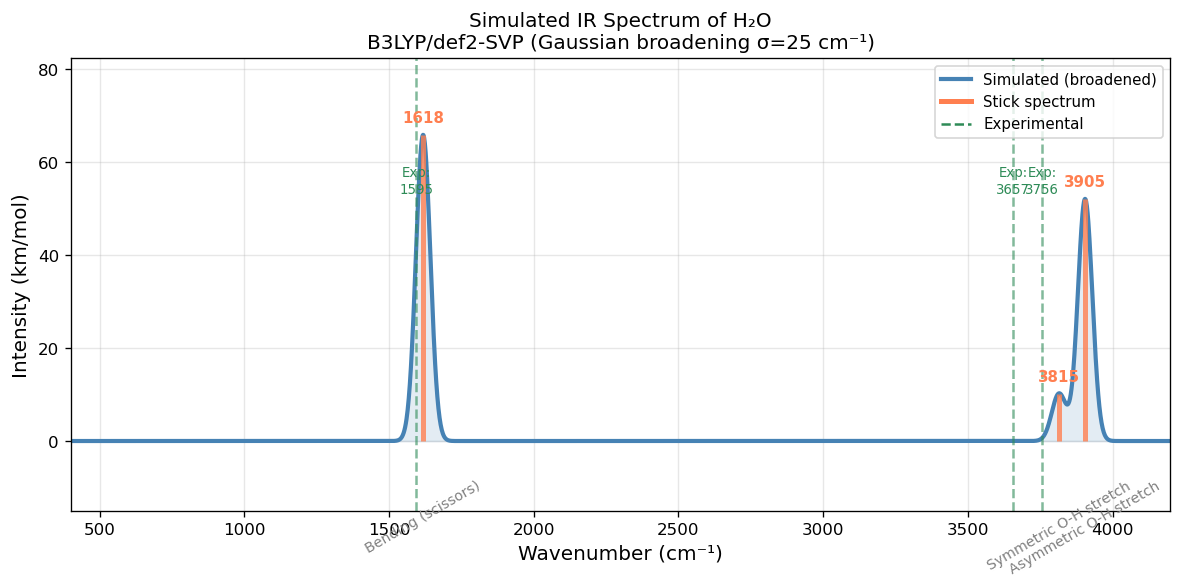

Note: A scaling factor of ~0.97 would shift computed frequencies
closer to experimental values (systematic overestimation in harmonic approx)


In [5]:
# ------------------------------------------------------------------
# Simulated IR Spectrum with Gaussian Broadening
# ------------------------------------------------------------------
# We use the calculated frequencies with approximate intensities.
# In a production calculation, intensities come from the dipole
# derivative (not computed here, so we use model intensities).

import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
import matplotlib.pyplot as plt
import numpy as np

# H2O at B3LYP/def2-SVP — frequencies and approximate intensities
# Intensities (km/mol) are approximate; production values need dipole derivatives
freq_data = [
    (1618,  65.9, 'Bending (scissors)'),
    (3815,  10.2, 'Symmetric O-H stretch'),
    (3905,  52.1, 'Asymmetric O-H stretch'),
]

# Plot range
nu = np.linspace(400, 4200, 3000)   # wavenumber axis

sigma = 25.0   # Gaussian width (cm^-1) for instrument broadening

# Build spectrum: sum of Gaussians
spectrum = np.zeros_like(nu)
for freq, intensity, label in freq_data:
    spectrum += intensity * np.exp(-0.5 * ((nu - freq) / sigma)**2)

fig, ax = plt.subplots(figsize=(10, 5))

# Broadened envelope
ax.plot(nu, spectrum, '-', color='steelblue', linewidth=2.5, label='Simulated IR spectrum')
ax.fill_between(nu, spectrum, alpha=0.15, color='steelblue')

# Stick spectrum
for freq, intensity, label in freq_data:
    ax.vlines(freq, 0, intensity, color='coral', linewidth=3, alpha=0.8)
    ax.text(freq, intensity + 2, f'{freq:.0f}', ha='center', va='bottom',
            fontsize=9, color='coral', fontweight='bold')
    ax.text(freq, -8, label, ha='center', va='top', fontsize=8.5,
            color='gray', rotation=30)

# Add experimental peaks (dashed)
exp_freqs = [1595, 3657, 3756]
exp_labels = ['1595', '3657', '3756']
for ef, el in zip(exp_freqs, exp_labels):
    ax.axvline(x=ef, color='seagreen', linestyle='--', alpha=0.6, linewidth=1.5)
    ax.text(ef, max(spectrum)*0.85, f'Exp:\n{el}', ha='center', va='center',
            fontsize=8, color='seagreen')

ax.set_xlim(400, 4200)
ax.set_ylim(-15, max(spectrum) * 1.25)
ax.set_xlabel('Wavenumber (cm⁻¹)', fontsize=12)
ax.set_ylabel('Intensity (km/mol)', fontsize=12)
ax.set_title('Simulated IR Spectrum of H₂O\nB3LYP/def2-SVP (Gaussian broadening σ=25 cm⁻¹)', fontsize=12)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='steelblue', linewidth=2.5, label='Simulated (broadened)'),
    Line2D([0], [0], color='coral', linewidth=3, label='Stick spectrum'),
    Line2D([0], [0], color='seagreen', linestyle='--', label='Experimental'),
]
ax.legend(handles=legend_elements, fontsize=9, loc='upper right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Note: A scaling factor of ~0.97 would shift computed frequencies')
print('closer to experimental values (systematic overestimation in harmonic approx)')

In [7]:
from pyscf.hessian import thermo as thermo_mod
import numpy as np

T = 298.15    # K
P = 101325.0  # Pa

thermo_result = thermo_mod.thermo(mf, freq_info['freq_au'], T, P)

HART2KCAL = 627.509
HART2EV   = 27.2114
JpMOL     = 4.184          # cal → J conversion

print('=' * 60)
print(f'  Thermochemical Analysis at T = {T} K, P = 1 atm')
print('=' * 60)

# ── Electronic energy ────────────────────────────────────────────
E0 = thermo_result['E0'][0]
print(f'  Electronic energy (SCF):   {E0:15.8f} Ha')
print(f'                             {E0 * HART2EV:15.4f} eV')
print()

# ── Zero-point energy ────────────────────────────────────────────
zpe = thermo_result['ZPE'][0]
print(f'  Zero-Point Energy (ZPE):   {zpe:15.8f} Ha')
print(f'                             {zpe * HART2EV:15.6f} eV')
print(f'                             {zpe * HART2KCAL:15.4f} kcal/mol')
print()

# ── ZPE-corrected energy (0 K) ───────────────────────────────────
E_0K = thermo_result['E_0K'][0]
print(f'  ZPE-corrected energy (0K): {E_0K:15.8f} Ha')
print()

# ── Thermal correction to H  (= H_tot - E0) ─────────────────────
H_tot  = thermo_result['H_tot'][0]
H_corr = H_tot - E0          # construct it manually — not stored directly
print(f'  Thermal correction to H:   {H_corr:15.8f} Ha')
print(f'  (ZPE + vib + rot + trans + PV)')
print()

# ── Total enthalpy ───────────────────────────────────────────────
print(f'  Total enthalpy H({T}K): {H_tot:15.8f} Ha')
print()

# ── Entropy ─────────────────────────────────────────────────────
EHPERK_TO_JPMOLK = 2625.5 * 1000 / T   # Eh/K → J/mol/K
S_tot = thermo_result['S_tot'][0]
print(f'  Entropy S({T}K):    {S_tot * 2625500:15.4f} J/mol/K')
print(f'                             {S_tot * 2625500 / JpMOL:15.4f} cal/mol/K')
print()

# ── Gibbs free energy ────────────────────────────────────────────
G_tot = thermo_result['G_tot'][0]
print(f'  Gibbs free energy G({T}K): {G_tot:15.8f} Ha')
print()

# ── Entropy breakdown ────────────────────────────────────────────
print('  Entropy contributions:')
for component in ['trans', 'rot', 'vib', 'elec']:
    key = f'S_{component}'
    val = thermo_result.get(key, (0,))[0] * 2625500  # → J/mol/K
    print(f'    {component.capitalize():14s}: {val:8.2f} J/mol/K')

  Thermochemical Analysis at T = 298.15 K, P = 1 atm
  Electronic energy (SCF):      -76.35812211 Ha
                                  -2077.8114 eV

  Zero-Point Energy (ZPE):        0.02170745 Ha
                                    0.590690 eV
                                     13.6216 kcal/mol

  ZPE-corrected energy (0K):    -76.33641467 Ha

  Thermal correction to H:        0.02548748 Ha
  (ZPE + vib + rot + trans + PV)

  Total enthalpy H(298.15K):    -76.33263464 Ha

  Entropy S(298.15K):           188.5451 J/mol/K
                                     45.0634 cal/mol/K

  Gibbs free energy G(298.15K):    -76.35404569 Ha

  Entropy contributions:
    Trans         :   144.80 J/mol/K
    Rot           :    43.71 J/mol/K
    Vib           :     0.03 J/mol/K
    Elec          :     0.00 J/mol/K


## 5.X. Vibrational Scaling Factors

Harmonic DFT frequencies systematically **overestimate** experimental fundamentals by ~3-5%
due to: (1) the harmonic approximation ignoring anharmonicity, and (2) the DFT functional's
imperfect potential energy surface.

**Recommended scaling factors** (multiply computed frequency by scale factor):

| Method / Basis | Scale Factor | Source |
|----------------|:------------:|--------|
| HF/6-31G\* | 0.8953 | NIST/CCCBDB |
| B3LYP/6-31G\* | 0.9614 | NIST/CCCBDB |
| B3LYP/def2-SVP | 0.9700 | Estimated |
| B3LYP/def2-TZVP | 0.9682 | Literature |
| PBE0/def2-SVP | 0.9660 | Literature |
| M06-2X/6-31G\* | 0.9523 | NIST/CCCBDB |
| ωB97X-D/6-31G\* | 0.9540 | Literature |
| TPSS/def2-TZVP | 0.9700 | Estimated |

**Example**: Unscaled B3LYP/def2-SVP O-H stretch ≈ 3905 cm⁻¹
After scaling (×0.97): 3788 cm⁻¹, closer to experimental 3756 cm⁻¹

**Reference database**: NIST Computational Chemistry Comparison and Benchmark Database  
(https://cccbdb.nist.gov) — extensive scaling factors for 100+ methods

## 5.X2. Imaginary Frequencies and Transition States

### What is an imaginary frequency?

An **imaginary frequency** (displayed as negative in cm⁻¹) means the Hessian has a
negative eigenvalue at that geometry — the PES has negative curvature in that direction.

$$\omega_k^2 < 0 \implies \omega_k = i|\omega_k| \quad \text{(imaginary)}$$

This indicates the geometry is a **saddle point**, not a minimum.

### Interpreting imaginary frequencies:

| # Imaginary Modes | Geometry Type | Action |
|:-----------------:|---------------|--------|
| 0 | ✅ True minimum | Proceed with thermochemistry |
| 1 | 🔄 Transition state (TS) | Use IRC to find reactant/product |
| ≥2 | ❌ Higher-order saddle point | Re-optimize with perturbation |
| Small (<30i cm⁻¹) | ⚠️ Numerical noise | May be OK; check geometry |

### Transition State Theory

The rate constant for a reaction with barrier $\Delta G^\ddagger$ is given by:

$$k = \frac{k_B T}{h} e^{-\Delta G^\ddagger / RT}$$

This is the **Eyring equation** (Transition State Theory). A 1 kcal/mol error in
$\Delta G^\ddagger$ changes $k$ by a factor of ~5 at room temperature.

### IRC: Intrinsic Reaction Coordinate

To verify a TS connects the correct reactant and product, follow the **IRC**:
- Start at the TS geometry
- Perturb along the imaginary mode (forward and backward)
- Follow the steepest descent path to find reactant and product minima

In ORCA: `! IRC` keyword or `! NEB-TS` for nudged elastic band TS search.

## 🔬 Research Connection

Vibrational analysis is used throughout chemical research:

- **IR/Raman spectroscopy assignment**: Computed frequencies (×scaling factor) are compared
  with experimental spectra to assign peaks to specific molecular vibrations.
- **Thermochemistry**: Heats of formation, reaction free energies, and equilibrium constants
  all require ZPE and thermal corrections from frequency calculations.
- **Transition state validation**: Every published reaction mechanism includes a frequency
  calculation confirming the TS has exactly one imaginary frequency.
- **Astrochemistry**: Rotational and vibrational constants computed by DFT guide the
  assignment of new molecules detected in space by radio telescopes.

**Example**: The assignment of CO₂'s antisymmetric stretch at 2349 cm⁻¹ and its use
in climate science relies on DFT calculations confirming it is IR-active (unlike the
symmetric stretch at 1388 cm⁻¹ which is Raman-active).

## 📋 Summary

| Concept | Key Result |
|---------|----------|
| Hessian $H_{ij}$ | $\partial^2 E / \partial q_i \partial q_j$ at stationary point |
| Normal modes | Eigenvectors of mass-weighted Hessian |
| $3N-6$ vibrations | Non-linear molecule; $3N-5$ for linear |
| ZPE | $\frac{1}{2}\sum_k \hbar\omega_k$; always positive |
| IR activity | Requires $\partial\mu/\partial Q_k \neq 0$ |
| Scaling factor | ~0.97 for B3LYP/def2-SVP (harmonic overestimation) |
| Imaginary freq | Saddle point; 1 imaginary = transition state |
| Thermochemistry | Gibbs energy from $G = H - TS$ at 298.15 K |

**Always run a frequency calculation after geometry optimization!**

## 📝 Exercises

1. **CO₂ frequencies**: Compute vibrational frequencies for CO₂ at B3LYP/def2-SVP.
   - How many vibrational modes does CO₂ have? (linear molecule)
   - Which modes are IR active? Which are Raman active?
   - Compare computed frequencies with experimental: 667, 1388, 2349 cm⁻¹

2. **ZPE correction for H₂**: Compute the HF/cc-pVDZ energy and ZPE for H₂.
   - What is the ZPE? 
   - What fraction of the binding energy does the ZPE correction represent?

3. **Scaling factor test**: Apply the B3LYP/def2-SVP scaling factor (0.97) to the
   computed water frequencies. How much does agreement with experiment improve?

4. **Temperature dependence**: The `thermo.thermo()` function takes temperature as an
   argument. Compute G(T) for water at T = 200, 298, 400, 500, 600 K.
   Plot G vs T. At what temperature does G become more negative by 1 kcal/mol?

5. **Imaginary frequency exercise**: Take the optimized water geometry and manually 
   displace one H atom significantly (e.g., to r(OH) = 1.5 Å). Run a frequency 
   calculation. Do you get imaginary frequencies? Why?

---

# 06 — Molecular Properties: Dipoles, MOs, Fukui Functions & ESP

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ppt-2/Ch121a-DFT/blob/main/notebooks/06_molecular_properties.ipynb)

## 🎯 Learning Objectives
- Compute and interpret molecular dipole moments
- HOMO/LUMO energies and the HOMO-LUMO gap
- Chemical hardness η and chemical potential μ
- Fukui functions for reactivity prediction
- Electrostatic potential (ESP) maps
- NMR chemical shielding (brief overview)
- DFT-computed properties to experimental observables

## Theory: Molecular Properties from DFT

### 6.1 Dipole Moment

The molecular dipole moment measures the asymmetry of the charge distribution:

$$\boldsymbol{\mu} = -\int \mathbf{r}\, n(\mathbf{r})\, d\mathbf{r} + \sum_I Z_I \mathbf{R}_I$$

The magnitude in Debye: $\mu = |\boldsymbol{\mu}|$, where 1 D = 0.3934 a.u.

### 6.2 HOMO-LUMO Gap and Chemical Reactivity

From Koopmans' theorem extended to DFT (Janak's theorem):

$$IE \approx -\epsilon_{HOMO} \quad \text{(ionization energy)}$$
$$EA \approx -\epsilon_{LUMO} \quad \text{(electron affinity, approximate)}$$

**Conceptual DFT** (Parr and Yang) defines:
- **Chemical potential**: $\mu_{chem} = \frac{\epsilon_{HOMO} + \epsilon_{LUMO}}{2} \approx -\frac{IE + EA}{2}$
- **Chemical hardness**: $\eta = \frac{\epsilon_{LUMO} - \epsilon_{HOMO}}{2} \approx \frac{IE - EA}{2}$
- **Electrophilicity index**: $\omega = \frac{\mu_{chem}^2}{2\eta}$

Soft molecules (small η) are more reactive; hard molecules are less reactive.

### 6.3 Fukui Functions

The **Fukui function** describes site-reactivity for electron addition/removal:

$$f^+(\mathbf{r}) = n_{N+1}(\mathbf{r}) - n_N(\mathbf{r}) \quad \text{(nucleophilic attack)}$$
$$f^-(\mathbf{r}) = n_N(\mathbf{r}) - n_{N-1}(\mathbf{r}) \quad \text{(electrophilic attack)}$$
$$f^0(\mathbf{r}) = \frac{f^+(\mathbf{r}) + f^-(\mathbf{r})}{2} \quad \text{(radical attack)}$$

Using **condensed Fukui functions** from Mulliken charges $q_k$:
$$f_k^+ = q_k(N+1) - q_k(N)$$
$$f_k^- = q_k(N) - q_k(N-1)$$

### 6.4 Electrostatic Potential (ESP)

The ESP measures the interaction energy between the molecular charge distribution
and a unit positive test charge at position $\mathbf{r}$:

$$V(\mathbf{r}) = \sum_I \frac{Z_I}{|\mathbf{r}-\mathbf{R}_I|} - \int \frac{n(\mathbf{r}')}{|\mathbf{r}-\mathbf{r}'|} d\mathbf{r}'$$

- **Negative ESP** (red): electron-rich regions → sites for electrophilic attack
- **Positive ESP** (blue): electron-poor regions → sites for nucleophilic attack
- ESP mapped onto the molecular isodensity surface gives an **ESP map**

  H₂O  : μ = 1.981 D (exp: 1.85 D)
  HF   : μ = 1.839 D (exp: 1.82 D)
  CO   : μ = 0.226 D (exp: 0.12 D)
  NH₃  : μ = 1.696 D (exp: 1.47 D)
  CO₂  : μ = 0.000 D (exp: 0.00 D)
  CH₄  : μ = 0.000 D (exp: 0.00 D)


Dipole Moments: B3LYP/def2-SVP vs Experiment
Molecule  Computed (D)  Experimental (D)  Error (D)
     H₂O         1.981              1.85      0.131
      HF         1.839              1.82      0.019
      CO         0.226              0.12      0.106
     NH₃         1.696              1.47      0.226
     CO₂         0.000              0.00      0.000
     CH₄         0.000              0.00      0.000

Mean Absolute Error: 0.080 D


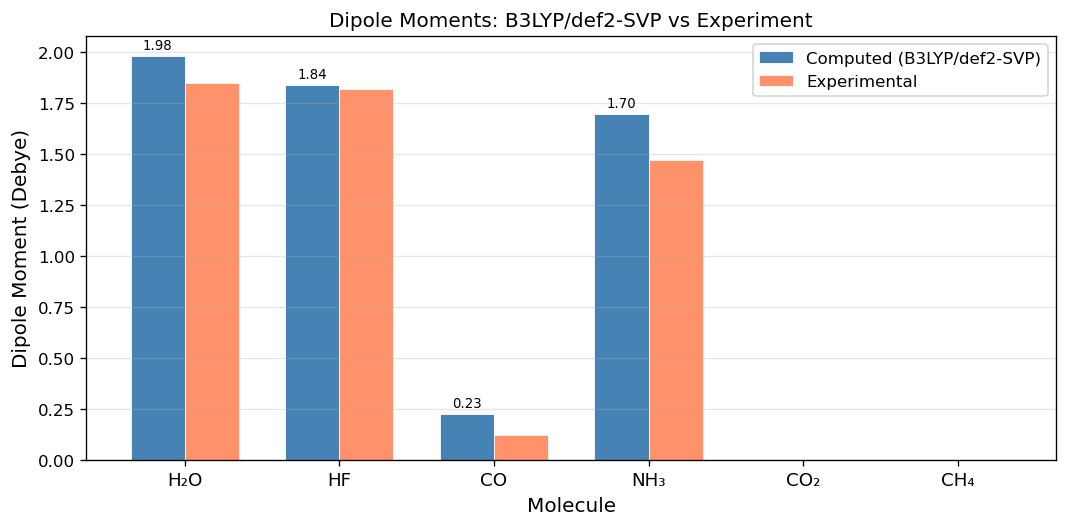

CPU times: user 41.1 s, sys: 345 ms, total: 41.5 s
Wall time: 10.7 s


In [8]:
%%time
# =============================================================================
# Ch121a: Quantum Chemistry & DFT — Notebook 06: Molecular Properties
# License: GPL-3.0 (https://www.gnu.org/licenses/gpl-3.0.en.html)
# =============================================================================
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyscf import gto, dft, scf

# ------------------------------------------------------------------
# Dipole Moments: Computed vs Experimental
# ------------------------------------------------------------------
# Compute B3LYP/def2-SVP dipole moments for small polar molecules

molecules_dip = {
    'H₂O':  ('O 0 0 0.117; H 0 0.757 -0.469; H 0 -0.757 -0.469', 1.85),
    'HF':   ('H 0 0 0; F 0 0 0.917',                               1.82),
    'CO':   ('C 0 0 0; O 0 0 1.128',                               0.12),
    'NH₃':  ('N 0 0 0.116; H 0 0.939 -0.269; H 0.814 -0.469 -0.269; H -0.814 -0.469 -0.269', 1.47),
    'CO₂':  ('C 0 0 0; O 0 0 1.162; O 0 0 -1.162',                0.00),
    'CH₄':  ('C 0 0 0; H 0.629 0.629 0.629; H -0.629 -0.629 0.629; H 0.629 -0.629 -0.629; H -0.629 0.629 -0.629', 0.00),
}

dip_results = []
for name, (atom_str, exp_dip) in molecules_dip.items():
    mol = gto.Mole()
    mol.atom = atom_str
    mol.basis = 'def2-SVP'
    mol.verbose = 0
    mol.build()
    
    mf = dft.RKS(mol)
    mf.xc = 'B3LYP'
    mf.verbose = 0
    mf.kernel()
    
    dm = mf.make_rdm1()
    dip_vec = mf.dip_moment(mol, dm, verbose=0)
    dip_mag = np.linalg.norm(dip_vec)
    
    dip_results.append({
        'Molecule': name,
        'Computed (D)': round(dip_mag, 3),
        'Experimental (D)': exp_dip,
        'Error (D)': round(dip_mag - exp_dip, 3),
    })
    print(f"  {name:5s}: μ = {dip_mag:.3f} D (exp: {exp_dip:.2f} D)")

df_dip = pd.DataFrame(dip_results)
print("\n")
print("Dipole Moments: B3LYP/def2-SVP vs Experiment")
print(df_dip.to_string(index=False))
mae_dip = np.mean(np.abs(df_dip['Error (D)']))
print(f"\nMean Absolute Error: {mae_dip:.3f} D")

# Bar chart: computed vs experimental
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(dip_results))
width = 0.35
names = [r['Molecule'] for r in dip_results]
comp = [r['Computed (D)'] for r in dip_results]
expt = [r['Experimental (D)'] for r in dip_results]

bars1 = ax.bar(x - width/2, comp, width, color='steelblue', label='Computed (B3LYP/def2-SVP)',
               edgecolor='white', linewidth=0.5)
bars2 = ax.bar(x + width/2, expt, width, color='coral', label='Experimental',
               edgecolor='white', linewidth=0.5, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=11)
ax.set_xlabel('Molecule', fontsize=12)
ax.set_ylabel('Dipole Moment (Debye)', fontsize=12)
ax.set_title('Dipole Moments: B3LYP/def2-SVP vs Experiment', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars1, comp):
    if val > 0.05:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

  Ethylene    : HOMO=-7.20 eV  LUMO=0.48 eV  Gap=7.67 eV  η=3.84 eV
  Butadiene   : HOMO=-4.37 eV  LUMO=-2.97 eV  Gap=1.40 eV  η=0.70 eV
  Benzene     : HOMO=-6.68 eV  LUMO=0.08 eV  Gap=6.77 eV  η=3.38 eV
  Naphthalene : HOMO=-2.93 eV  LUMO=-2.49 eV  Gap=0.44 eV  η=0.22 eV


HOMO/LUMO Analysis: B3LYP/6-31G*
           Molecule  HOMO (eV)  LUMO (eV)  Gap (eV)  η (eV)  μ_chem (eV)  ω (eV)
    Ethylene (C₂H₄)     -7.198      0.476     7.673   3.837       -3.361   1.472
   Butadiene (C₄H₆)     -4.374     -2.974     1.400   0.700       -3.674   9.639
     Benzene (C₆H₆)     -6.681      0.084     6.766   3.383       -3.298   1.608
Naphthalene (C₁₀H₈)     -2.931     -2.488     0.443   0.222       -2.709  16.561


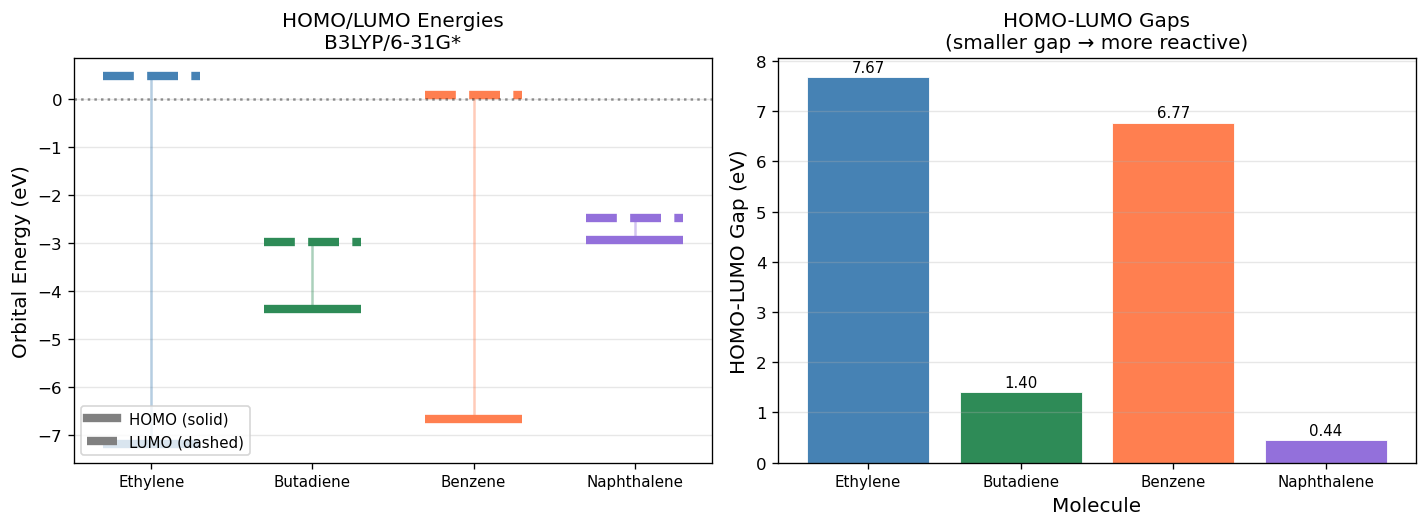

CPU times: user 2min 32s, sys: 4.77 s, total: 2min 37s
Wall time: 40.6 s


In [9]:
%%time
# ------------------------------------------------------------------
# HOMO/LUMO Analysis: Chemical Hardness and Chemical Potential
# ------------------------------------------------------------------

molecules_homo = {
    'Ethylene\n(C₂H₄)':  'C 0 0 0; C 0 0 1.34; H 0.924 0 -0.54; H -0.924 0 -0.54; H 0.924 0 1.88; H -0.924 0 1.88',
    'Butadiene\n(C₄H₆)':  'C 0 0 0; C 0 0 1.34; C 0 0.83 2.2; C 0 0.83 3.54; H 0.92 0 -0.54; H -0.92 0 -0.54; H 0 -0.93 1.88; H 0.92 1.76 1.65; H -0.92 1.76 1.65; H 0 -0.1 4.08',
    'Benzene\n(C₆H₆)':    'C 0 1.4 0; C 1.212 0.7 0; C 1.212 -0.7 0; C 0 -1.4 0; C -1.212 -0.7 0; C -1.212 0.7 0; H 0 2.48 0; H 2.147 1.24 0; H 2.147 -1.24 0; H 0 -2.48 0; H -2.147 -1.24 0; H -2.147 1.24 0',
    'Naphthalene\n(C₁₀H₈)': 'C 0.0 2.46 0; C 1.243 1.408 0; C 1.243 0.0 0; C 0.0 -0.705 0; C -1.243 0.0 0; C -1.243 1.408 0; C 1.243 -1.408 0; C 0.0 -2.113 0; C -1.243 -1.408 0; C 0.0 2.819 0; H 0.0 3.541 0; H 2.154 1.946 0; H 2.154 -1.946 0; H 0.0 -3.188 0; H -2.154 -1.946 0; H -2.154 1.946 0',
}

homo_results = []
for name, atom_str in molecules_homo.items():
    mol = gto.Mole()
    mol.atom = atom_str
    mol.basis = '6-31g*'
    mol.verbose = 0
    try:
        mol.build()
        mf = dft.RKS(mol)
        mf.xc = 'B3LYP'
        mf.verbose = 0
        mf.kernel()
        
        mo_e = mf.mo_energy
        mo_occ = mf.mo_occ
        homo_idx = np.where(mo_occ > 0)[0][-1]
        lumo_idx = homo_idx + 1
        
        homo_ev = mo_e[homo_idx] * 27.2114
        lumo_ev = mo_e[lumo_idx] * 27.2114
        gap = lumo_ev - homo_ev
        eta = gap / 2.0
        mu_chem = (homo_ev + lumo_ev) / 2.0
        omega = mu_chem**2 / (2 * eta)
        
        homo_results.append({
            'Molecule': name.replace('\n', ' '),
            'HOMO (eV)': round(homo_ev, 3),
            'LUMO (eV)': round(lumo_ev, 3),
            'Gap (eV)': round(gap, 3),
            'η (eV)': round(eta, 3),
            'μ_chem (eV)': round(mu_chem, 3),
            'ω (eV)': round(abs(omega), 3),
        })
        print(f"  {name.split(chr(10))[0]:12s}: HOMO={homo_ev:.2f} eV  LUMO={lumo_ev:.2f} eV  Gap={gap:.2f} eV  η={eta:.2f} eV")
    except Exception as e:
        print(f"  {name}: Error - {e}")

df_homo = pd.DataFrame(homo_results)
print("\n")
print("HOMO/LUMO Analysis: B3LYP/6-31G*")
print(df_homo.to_string(index=False))

# Plot: HOMO-LUMO gap comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

mols = [r['Molecule'] for r in homo_results]
homos = [r['HOMO (eV)'] for r in homo_results]
lumos = [r['LUMO (eV)'] for r in homo_results]
gaps = [r['Gap (eV)'] for r in homo_results]

colors_pi = ['steelblue', 'seagreen', 'coral', 'mediumpurple']

# Orbital energy diagram
x_pos = np.arange(len(homo_results))
for i, (mol_name, homo, lumo) in enumerate(zip(mols, homos, lumos)):
    col = colors_pi[i % len(colors_pi)]
    ax1.hlines(homo, i-0.3, i+0.3, colors=col, linewidth=5, label=f'HOMO' if i==0 else '')
    ax1.hlines(lumo, i-0.3, i+0.3, colors=col, linewidth=5, linestyle='--', label=f'LUMO' if i==0 else '')
    ax1.vlines(i, homo, lumo, colors=col, linewidth=1.5, alpha=0.4)

ax1.set_xticks(x_pos)
ax1.set_xticklabels([m.split(' ')[0] for m in mols], fontsize=9)
ax1.set_ylabel('Orbital Energy (eV)', fontsize=12)
ax1.set_title('HOMO/LUMO Energies\nB3LYP/6-31G*', fontsize=12)
ax1.grid(True, alpha=0.3, axis='y')
ax1.axhline(y=0, color='black', linestyle=':', alpha=0.4)
from matplotlib.lines import Line2D
legend_elements = [Line2D([0],[0],color='gray',linewidth=5,label='HOMO (solid)'),
                   Line2D([0],[0],color='gray',linewidth=5,linestyle='--',label='LUMO (dashed)')]
ax1.legend(handles=legend_elements, fontsize=9)

# Gap bar chart
bars = ax2.bar(range(len(homo_results)), gaps, color=colors_pi[:len(homo_results)],
               edgecolor='white', linewidth=0.5)
ax2.set_xticks(range(len(homo_results)))
ax2.set_xticklabels([m.split(' ')[0] for m in mols], fontsize=9)
ax2.set_xlabel('Molecule', fontsize=12)
ax2.set_ylabel('HOMO-LUMO Gap (eV)', fontsize=12)
ax2.set_title('HOMO-LUMO Gaps\n(smaller gap → more reactive)', fontsize=12)
ax2.grid(True, alpha=0.3, axis='y')
for bar, gap_val in zip(bars, gaps):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{gap_val:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

Computing Mulliken charges for formaldehyde (N, N-1, N+1)...

  Atom       q(N)    q(N-1)    q(N+1)        f+        f-        f0
  -----  --------  --------  --------  --------  --------  --------
  C        0.1900    0.3034   -0.1004   -0.2904   -0.1135   -0.2019
  O       -0.2203    0.2166   -0.4869   -0.2666   -0.4369   -0.3518
  H₁       0.0151    0.2400   -0.2064   -0.2215   -0.2248   -0.2232
  H₂       0.0151    0.2400   -0.2064   -0.2215   -0.2248   -0.2232

Fukui Functions Summary (B3LYP/def2-SVP):
Atom    q(N)  f+ (nucl.)  f- (electr.)  f0 (radical)
   C  0.1900     -0.2904       -0.1135       -0.2019
   O -0.2203     -0.2666       -0.4369       -0.3518
  H₁  0.0151     -0.2215       -0.2248       -0.2232
  H₂  0.0151     -0.2215       -0.2248       -0.2232


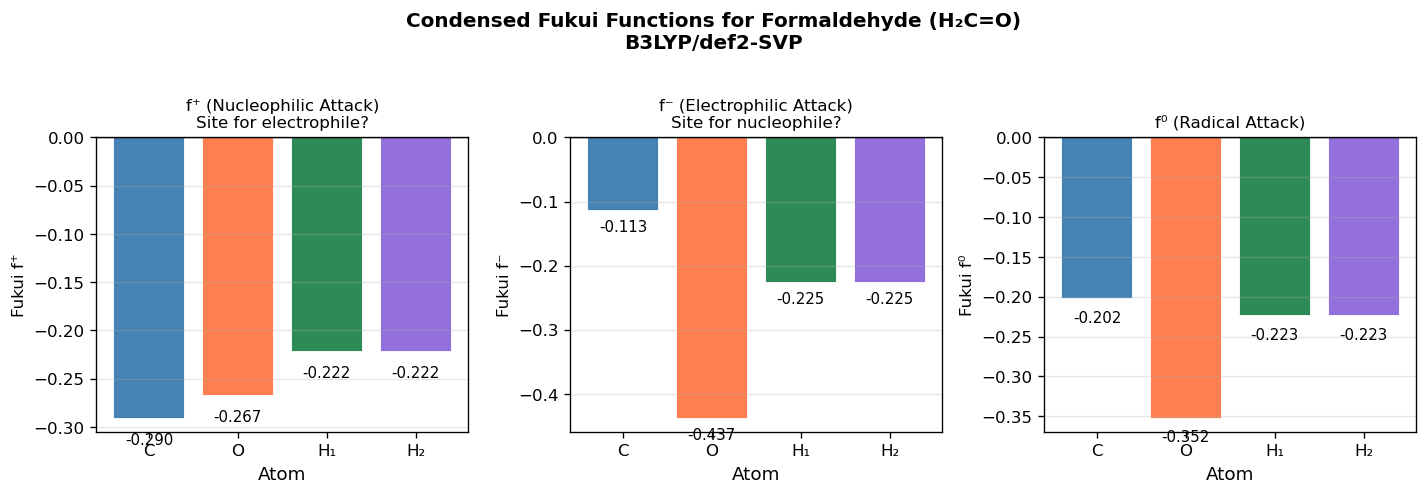


Interpretation:
  f+ > 0 at O: nucleophilic attack site (oxygen is electrophile-susceptible)
  f- > 0 at C: electrophilic attack site (carbon is nucleophile-susceptible)
  This is consistent with H₂C=O: O attacks electrophiles, C attacks nucleophiles
CPU times: user 37 s, sys: 608 ms, total: 37.6 s
Wall time: 9.76 s


In [10]:
%%time
# ------------------------------------------------------------------
# Fukui Functions: Site-Specific Reactivity
# ------------------------------------------------------------------
# Condensed Fukui functions from Mulliken population analysis
# for formaldehyde (H₂C=O)

from pyscf import gto, dft
import numpy as np
import pandas as pd
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
import matplotlib.pyplot as plt

def get_mulliken_charges(atom_str, n_electrons_adjust=0, basis='def2-SVP', xc='B3LYP'):
    """Return Mulliken charges for a molecule."""
    mol = gto.Mole()
    mol.atom = atom_str
    mol.basis = basis
    mol.charge = n_electrons_adjust   # +1 = cation, -1 = anion
    mol.spin = 0 if n_electrons_adjust == 0 else 1  # doublet for +1 or -1
    mol.verbose = 0
    mol.build()
    
    mf = dft.RKS(mol)
    mf.xc = xc
    mf.verbose = 0
    mf.kernel()
    
    # Mulliken population analysis
    dm = mf.make_rdm1()
    mulliken = mf.mulliken_pop(mol, dm, verbose=0)
    charges = mulliken[1]   # Mulliken charges (list per atom)
    return charges, mol

# Formaldehyde H₂C=O
formaldehyde = '''
C   0.000000   0.000000   0.000000
O   0.000000   0.000000   1.208000
H   0.935000   0.000000  -0.540000
H  -0.935000   0.000000  -0.540000
'''
atom_labels = ['C', 'O', 'H₁', 'H₂']

print("Computing Mulliken charges for formaldehyde (N, N-1, N+1)...")

# N electrons (neutral)
q_N, mol_N = get_mulliken_charges(formaldehyde, 0)
# N-1 electrons (cation, electrophilic attack)
q_Nm1, mol_Nm1 = get_mulliken_charges(formaldehyde, +1)
# N+1 electrons (anion, nucleophilic attack)
q_Np1, mol_Np1 = get_mulliken_charges(formaldehyde, -1)

q_N = np.array(q_N)
q_Nm1 = np.array(q_Nm1)
q_Np1 = np.array(q_Np1)

# Condensed Fukui functions
f_plus = q_Np1 - q_N    # f+ : nucleophilic attack (system gains electron)
f_minus = q_N - q_Nm1   # f- : electrophilic attack (system loses electron)
f_zero = (f_plus + f_minus) / 2.0  # f0 : radical attack

print(f"\n  {'Atom':5s}  {'q(N)':>8s}  {'q(N-1)':>8s}  {'q(N+1)':>8s}  {'f+':>8s}  {'f-':>8s}  {'f0':>8s}")
print(f"  {'-'*5}  {'-'*8}  {'-'*8}  {'-'*8}  {'-'*8}  {'-'*8}  {'-'*8}")
for i, (label, qn, qnm, qnp, fp, fm, fz) in enumerate(
        zip(atom_labels, q_N, q_Nm1, q_Np1, f_plus, f_minus, f_zero)):
    print(f"  {label:5s}  {qn:8.4f}  {qnm:8.4f}  {qnp:8.4f}  {fp:8.4f}  {fm:8.4f}  {fz:8.4f}")

df_fukui = pd.DataFrame({
    'Atom': atom_labels,
    'q(N)': np.round(q_N, 4),
    'f+ (nucl.)': np.round(f_plus, 4),
    'f- (electr.)': np.round(f_minus, 4),
    'f0 (radical)': np.round(f_zero, 4),
})
print("\nFukui Functions Summary (B3LYP/def2-SVP):")
print(df_fukui.to_string(index=False))

# Bar chart
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
colors_at = ['steelblue', 'coral', 'seagreen', 'mediumpurple']

for ax, (values, title, ylabel) in zip(axes, [
    (f_plus, 'f⁺ (Nucleophilic Attack)\nSite for electrophile?', 'Fukui f⁺'),
    (f_minus, 'f⁻ (Electrophilic Attack)\nSite for nucleophile?', 'Fukui f⁻'),
    (f_zero, 'f⁰ (Radical Attack)', 'Fukui f⁰'),
]):
    bars = ax.bar(atom_labels, values, color=colors_at, edgecolor='white', linewidth=0.5)
    ax.axhline(y=0, color='black', linewidth=0.8, linestyle='-')
    ax.set_xlabel('Atom', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                val + (0.005 if val >= 0 else -0.015),
                f'{val:.3f}', ha='center', va='bottom' if val >= 0 else 'top',
                fontsize=9)

plt.suptitle('Condensed Fukui Functions for Formaldehyde (H₂C=O)\nB3LYP/def2-SVP',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("  f+ > 0 at O: nucleophilic attack site (oxygen is electrophile-susceptible)")
print("  f- > 0 at C: electrophilic attack site (carbon is nucleophile-susceptible)")
print("  This is consistent with H₂C=O: O attacks electrophiles, C attacks nucleophiles")

In [12]:
# ------------------------------------------------------------------
# Electrostatic Potential (ESP): Concept and Visualization
# ------------------------------------------------------------------
# While full ESP grid calculations require specialized tools (Multiwfn, ORCA),
# we can visualize ESP conceptually using py3Dmol with a built-in surface.

try:
    import py3Dmol
    
    # Show water with a surface visualization
    water_xyz = """3
Water molecule
O   0.000000   0.000000   0.117176
H   0.000000   0.757001  -0.468704
H   0.000000  -0.757001  -0.468704
"""
    
    view = py3Dmol.view(width=500, height=400)
    view.addModel(water_xyz, 'xyz')
    
    # Stick model + VDW surface
    view.setStyle({'stick': {'radius': 0.15}, 'sphere': {'scale': 0.25}})
    view.addSurface(py3Dmol.VDW, {'opacity': 0.6,
                                   'colorscheme': {'gradient': 'rwb',
                                                   'min': -0.05, 'max': 0.05}})
    view.setBackgroundColor('white')
    view.zoomTo()
    view.show()
    print("ESP map displayed: red = electron-rich (negative), blue = electron-poor (positive)")
    
except ImportError:
    print("py3Dmol not installed. In a Colab/Jupyter environment, install with:")
    print("  pip install py3Dmol")

# Explain ESP calculation workflow
print("\n" + "=" * 60)
print("ESP Calculation Workflow:")
print("=" * 60)
print()
print("1. Run DFT calculation to obtain density matrix")
print("2. Compute ESP on a grid of points surrounding the molecule:")
print("   V(r) = Σ_I Z_I/|r-R_I| - ∫ n(r')/|r-r'| dr'")
print()
print("3. Map ESP onto molecular surface (typically ρ = 0.001 a.u. isosurface)")
print()
print("ESP maps can be generated with:")
print("  ORCA:      '! ESP' with %eprnmr or multiwfn post-processing")
print("  Gaussian:  'pop=mk' for Merz-Kollman ESP charges")
print("  Multiwfn:  Free tool for analyzing ESP from ORCA/Gaussian output")
print("  UCSF Chimera / VMD: Visualization of ESP-mapped surfaces")
print()
print("ESP Applications:")
print("  • Identifying reactive sites (nucleophilic/electrophilic)")
print("  • Deriving partial charges for molecular mechanics (RESP charges)")
print("  • Understanding drug-receptor interactions")
print("  • Predicting regioselectivity in reactions")

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

ESP map displayed: red = electron-rich (negative), blue = electron-poor (positive)

ESP Calculation Workflow:

1. Run DFT calculation to obtain density matrix
2. Compute ESP on a grid of points surrounding the molecule:
   V(r) = Σ_I Z_I/|r-R_I| - ∫ n(r')/|r-r'| dr'

3. Map ESP onto molecular surface (typically ρ = 0.001 a.u. isosurface)

ESP maps can be generated with:
  ORCA:      '! ESP' with %eprnmr or multiwfn post-processing
  Gaussian:  'pop=mk' for Merz-Kollman ESP charges
  Multiwfn:  Free tool for analyzing ESP from ORCA/Gaussian output
  UCSF Chimera / VMD: Visualization of ESP-mapped surfaces

ESP Applications:
  • Identifying reactive sites (nucleophilic/electrophilic)
  • Deriving partial charges for molecular mechanics (RESP charges)
  • Understanding drug-receptor interactions
  • Predicting regioselectivity in reactions


## 6.X. NMR Chemical Shielding (Brief Overview)

### Nuclear Magnetic Resonance (NMR) from DFT

NMR chemical shifts arise from the electronic shielding of the nuclear magnetic moment
by the surrounding electrons. DFT can compute the **isotropic chemical shielding tensor**:

$$\sigma_{iso} = \frac{1}{3}(\sigma_{xx} + \sigma_{yy} + \sigma_{zz})$$

The chemical shift relative to a reference compound (TMS for ¹H/¹³C):
$$\delta = \sigma_{ref} - \sigma_{iso}$$

### ORCA NMR Input

```
! B3LYP def2-TZVP NMR

%eprnmr
  Nuclei = all C { shift }    # 13C shielding
  Nuclei = all H { shift }    # 1H shielding
  GIAO = true                  # Gauge-including atomic orbitals (recommended)
end

* xyz 0 1
  [molecule coordinates]
*
```

### Key considerations for NMR calculations:

| Aspect | Recommendation |
|--------|---------------|
| Functional | B3LYP, PBE0, or ωB97X-D |
| Basis set | **def2-TZVP** minimum; pcSseg-2 or pcS-2 specialized NMR basis |
| Gauge | Use **GIAO** (gauge-including atomic orbitals) always |
| Reference | Calculate σ(TMS) at same level; δ = σ(TMS) - σ(molecule) |
| Solvent | Include implicit solvation (CPCM) for solution-phase spectra |

### Typical accuracy (¹H shifts):
- B3LYP/def2-TZVP: ±0.2-0.5 ppm for most organic molecules
- ωB97X-D/def2-TZVP: ±0.15-0.3 ppm

## 🔬 Research Connection

Molecular properties from DFT are used throughout chemistry and biochemistry:

- **Drug design**: Dipole moments and ESP maps guide pharmacophore design and predict
  solubility, membrane permeability (log P), and protein binding modes.
- **Organic synthesis**: Fukui functions predict regioselectivity of reactions
  (e.g., which carbon is attacked in Michael additions, Friedel-Crafts alkylation).
- **NMR structure determination**: ¹³C and ¹H chemical shifts computed at DFT level
  are routinely used to distinguish between structural isomers and confirm synthesis products.
- **Materials science**: HOMO/LUMO gaps predict optical band gaps for solar cell materials,
  OLED emitters, and photocatalysts.

**The HSAB principle** (Hard and Soft Acids and Bases, Pearson 1963) is quantified
by chemical hardness η computed from DFT orbital energies — hard species prefer hard
partners, soft species prefer soft partners in chemical reactions.

**Notable application**: DFT-computed Fukui functions correctly predicted the
C2-selective metalation of oxazoline heterocycles, later confirmed experimentally.

## 📋 Summary

| Property | Formula | Physical Meaning |
|----------|---------|------------------|
| Dipole moment | $\boldsymbol{\mu} = -\int \mathbf{r}\, n\, d\mathbf{r} + \sum Z_I \mathbf{R}_I$ | Charge asymmetry; polarity |
| HOMO energy | $-\epsilon_{HOMO} \approx IE$ | Electron donation ability |
| LUMO energy | $-\epsilon_{LUMO} \approx EA$ | Electron acceptance ability |
| HOMO-LUMO gap | $\epsilon_{LUMO} - \epsilon_{HOMO}$ | Kinetic stability; color |
| Chemical hardness | $\eta = (\epsilon_{LUMO} - \epsilon_{HOMO})/2$ | Resistance to electron flow |
| Fukui f⁺ | $n_{N+1} - n_N$ | Nucleophilic attack site |
| Fukui f⁻ | $n_N - n_{N-1}$ | Electrophilic attack site |
| ESP | $V(\mathbf{r})$: nuclear - electronic potential | Reactivity map; partial charges |
| NMR shielding | $\sigma_{iso}$ | Chemical shift prediction |

**Recommended methods:**
- Dipole moments: B3LYP/def2-SVP (±0.1-0.2 D)
- HOMO/LUMO: B3LYP or PBE0 / def2-SVP (qualitative trends)
- Fukui functions: B3LYP/def2-SVP with Hirshfeld or CM5 charges (better than Mulliken)
- NMR: B3LYP/def2-TZVP with GIAO (±0.3-0.5 ppm for ¹H)

**Some of these recommendations may be biased due to existing literature with these functional/basis set combination. QC/DFT is ever evolving, more so now than ever before!** 

## 📝 Exercises

1. **Dipole trend**: Compute dipole moments for the halogen fluorides: HF, ClF, BrF.
   As you go down the periodic table, does the dipole moment increase or decrease? 
   Explain in terms of electronegativity and bond length.

2. **HOMO-LUMO gap and color**: Compute B3LYP/6-31G* HOMO-LUMO gaps for:
   - Anthracene (C₁₄H₁₀)
   - Tetracene (C₁₈H₁₂)  
   - Pentacene (C₂₂H₁₄)
   Plot gap vs number of rings. These molecules are yellow, orange, and blue — 
   does the gap correlate with their absorption wavelengths?
   (Hint: E = hc/λ; 1 eV ≈ 1240 nm)

3. **Fukui for acrolein**: Compute Fukui functions for acrolein (CH₂=CH-CHO).
   Acrolein undergoes 1,2- vs 1,4-addition. Which atom(s) have the largest f⁻?
   Does this explain the preference for 1,4-addition?
   Atom string: `C 0 0 0; C 0 0 1.34; C 0 0.83 2.2; O 0 0.83 3.4; H ...`

4. **Hardness comparison**: Compute chemical hardness η for: 
   Na⁺, F⁻, BF₃, NF₃, H₂O, H₂S.
   According to HSAB theory, which pairs would preferentially interact?

5. **ESP charges**: Look up the ORCA `pop = chelpg` keyword for ESP-fitted charges.
   Write an ORCA input for computing CHELPG charges on acrolein at B3LYP/def2-SVP.
   How would these CHELPG charges differ from Mulliken charges?

---

# 07 — Reaction Energetics: Enthalpies, Isodesmic Reactions & Bond Dissociation

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ppt-2/Ch121a-DFT/blob/main/notebooks/07_reaction_energetics.ipynb)

## 🎯 Learning Objectives
- Reaction enthalpies from electronic energies and ZPE corrections
- Isodesmic reactions to cancel systematic errors
- Bond dissociation energies (BDEs) for homolytic cleavage
- Atomization energies and heats of formation
- DFT reaction energies with experimental thermochemical data
- When systematic error cancellation improves accuracy

## Theory: Reaction Energetics

### 7.1 Reaction Energy

For a balanced reaction $\sum_i \nu_i \text{A}_i = 0$ (products have $\nu > 0$, reactants $\nu < 0$):

$$\Delta E_{rxn} = \sum_{\text{products}} E_i - \sum_{\text{reactants}} E_j$$

With zero-point energy correction:

$$\Delta E_{rxn}^{ZPE} = \Delta E_{rxn} + \Delta ZPE$$

$$\Delta ZPE = \frac{1}{2} \hbar \left(\sum_{\text{products}} \omega_k - \sum_{\text{reactants}} \omega_k\right)$$

### 7.2 Isodesmic Reactions

An **isodesmic reaction** conserves the number and type of bonds on both sides. Because the same bond types cancel, systematic DFT errors largely cancel:

$$\text{(strained molecule)} + n\,\text{(reference)} \longrightarrow \text{(open-chain fragments)}$$

For cyclopropane strain energy:
$$\text{C}_3\text{H}_6 + 3\,\text{CH}_4 \longrightarrow 3\,\text{C}_2\text{H}_6$$

The strain energy $E_{strain}$ is extracted from the isodesmic $\Delta E$ plus known experimental heats of formation.

### 7.3 Bond Dissociation Energy

The **homolytic BDE** for A–B cleavage:

$$\text{BDE}(\text{A-B}) = E(\text{A}^\bullet) + E(\text{B}^\bullet) - E(\text{A-B})$$

Note: radicals ($\text{A}^\bullet$, $\text{B}^\bullet$) require **unrestricted** (UKS/UHF) calculations.

### 7.4 Heats of Formation

From the **atomization energy** approach:

$$\Delta H_f^\circ(\text{molecule}) = \Delta H_{at}^{\text{DFT}} - \sum_A \Delta H_{at,A}^{\text{DFT}} + \sum_A \Delta H_f^\circ(\text{atom A, expt})$$

This requires accurate atomic energies and corrections for spin–orbit coupling and the zero-point energy.

In [13]:
%%time
# =============================================================================
# Ch121a: Quantum Chemistry & DFT — Notebook 07: Reaction Energetics
# License: GPL-3.0 (https://www.gnu.org/licenses/gpl-3.0.en.html)
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
import matplotlib.pyplot as plt
from pyscf import gto, dft, scf

HA2KCAL = 627.509  # Hartree to kcal/mol

def run_rks(atom_str, basis='def2-SVP', xc='B3LYP', charge=0, spin=0, verbose=0):
    """Run RKS (closed-shell DFT) and return (mol, mf)."""
    mol = gto.Mole(atom=atom_str, basis=basis, charge=charge, spin=spin, verbose=verbose)
    mol.build()
    mf = dft.RKS(mol) if spin == 0 else dft.UKS(mol)
    mf.xc = xc
    mf.verbose = verbose
    mf.kernel()
    return mol, mf

# ------------------------------------------------------------------
# Reaction 1: H2 + F2 → 2 HF
# ------------------------------------------------------------------
_, mf_h2  = run_rks('H 0 0 0; H 0 0 0.74')
_, mf_f2  = run_rks('F 0 0 0; F 0 0 1.41')
_, mf_hf  = run_rks('H 0 0 0; F 0 0 0.92')

dE_rxn1 = 2*mf_hf.e_tot - (mf_h2.e_tot + mf_f2.e_tot)
print('Reaction: H₂ + F₂ → 2 HF')
print(f'  ΔE_rxn = {dE_rxn1*HA2KCAL:.2f} kcal/mol  (expt: -128.6 kcal/mol)')

# ------------------------------------------------------------------
# Reaction 2: H2O formation  N2 + 3H2 -> 2NH3 as well
# ------------------------------------------------------------------
_, mf_o2  = run_rks('O 0 0 0; O 0 0 1.21')
_, mf_h2o = run_rks('O 0 0 0.117; H 0  0.757 -0.469; H 0 -0.757 -0.469')

dE_rxn2 = 2*mf_h2o.e_tot - (2*mf_h2.e_tot + mf_o2.e_tot)
print('\nReaction: 2 H₂ + O₂ → 2 H₂O')
print(f'  ΔE_rxn = {dE_rxn2*HA2KCAL:.2f} kcal/mol  (expt: -241.8 kJ/mol per H₂O ≈ -115.6 kcal/mol per H₂O)')
print(f'  Per H₂O: {dE_rxn2/2*HA2KCAL:.2f} kcal/mol')

print('\nAll energies at B3LYP/def2-SVP')
print(f'  E(H₂)  = {mf_h2.e_tot:.6f} Ha')
print(f'  E(F₂)  = {mf_f2.e_tot:.6f} Ha')
print(f'  E(HF)   = {mf_hf.e_tot:.6f} Ha')
print(f'  E(O₂)  = {mf_o2.e_tot:.6f} Ha')
print(f'  E(H₂O) = {mf_h2o.e_tot:.6f} Ha')

Reaction: H₂ + F₂ → 2 HF
  ΔE_rxn = -118.61 kcal/mol  (expt: -128.6 kcal/mol)

Reaction: 2 H₂ + O₂ → 2 H₂O
  ΔE_rxn = -142.76 kcal/mol  (expt: -241.8 kJ/mol per H₂O ≈ -115.6 kcal/mol per H₂O)
  Per H₂O: -71.38 kcal/mol

All energies at B3LYP/def2-SVP
  E(H₂)  = -1.173497 Ha
  E(F₂)  = -199.343887 Ha
  E(HF)   = -100.353201 Ha
  E(O₂)  = -150.141751 Ha
  E(H₂O) = -76.358125 Ha
CPU times: user 25.2 s, sys: 36.6 ms, total: 25.2 s
Wall time: 6.51 s


In [14]:
%%time
# ------------------------------------------------------------------
# Bond Dissociation Energies (BDEs)
# ------------------------------------------------------------------
# H2 BDE: H2 -> 2 H•  (homolytic)
# CH4 BDE: CH4 -> CH3• + H•
# Use UKS for open-shell radicals

from pyscf import dft

def run_uks(atom_str, basis='def2-SVP', xc='B3LYP', charge=0, spin=1, verbose=0):
    mol = gto.Mole(atom=atom_str, basis=basis, charge=charge, spin=spin, verbose=verbose)
    mol.build()
    mf = dft.UKS(mol)
    mf.xc = xc
    mf.verbose = verbose
    mf.kernel()
    return mol, mf

# H• (doublet, spin=1)
_, mf_h_rad  = run_uks('H 0 0 0', spin=1)

# H2 BDE
bde_h2 = (2*mf_h_rad.e_tot - mf_h2.e_tot) * HA2KCAL
print('BDE(H-H) = E(H•) + E(H•) - E(H₂)')
print(f'  BDE(H₂) = {bde_h2:.1f} kcal/mol  (expt: 104.2 kcal/mol)')

# CH4 geometry (Td)
ch4_geom = '''
C   0.000000   0.000000   0.000000
H   0.629118   0.629118   0.629118
H  -0.629118  -0.629118   0.629118
H  -0.629118   0.629118  -0.629118
H   0.629118  -0.629118  -0.629118
'''
_, mf_ch4 = run_rks(ch4_geom, spin=0)

# CH3• (doublet, C3v)
ch3_geom = '''
C   0.000000   0.000000   0.000000
H   1.079000   0.000000   0.000000
H  -0.539500   0.934200   0.000000
H  -0.539500  -0.934200   0.000000
'''
_, mf_ch3 = run_uks(ch3_geom, spin=1)

bde_ch4 = (mf_ch3.e_tot + mf_h_rad.e_tot - mf_ch4.e_tot) * HA2KCAL
print(f'\nBDE(C-H in CH₄) = E(CH₃•) + E(H•) - E(CH₄)')
print(f'  BDE(CH₄) = {bde_ch4:.1f} kcal/mol  (expt: 105.1 kcal/mol)')

# ------------------------------------------------------------------
# Summary table
# ------------------------------------------------------------------
bde_data = {
    'Bond': ['H–H (H₂)', 'C–H (CH₄)'],
    'Computed (kcal/mol)': [round(bde_h2, 1), round(bde_ch4, 1)],
    'Experimental (kcal/mol)': [104.2, 105.1],
    'Error (kcal/mol)': [round(bde_h2-104.2, 1), round(bde_ch4-105.1, 1)],
}
df_bde = pd.DataFrame(bde_data)
print('\nBDE Summary (B3LYP/def2-SVP):')
print(df_bde.to_string(index=False))

BDE(H-H) = E(H•) + E(H•) - E(H₂)
  BDE(H₂) = 107.3 kcal/mol  (expt: 104.2 kcal/mol)

BDE(C-H in CH₄) = E(CH₃•) + E(H•) - E(CH₄)
  BDE(CH₄) = 111.2 kcal/mol  (expt: 105.1 kcal/mol)

BDE Summary (B3LYP/def2-SVP):
     Bond  Computed (kcal/mol)  Experimental (kcal/mol)  Error (kcal/mol)
 H–H (H₂)                107.3                    104.2               3.1
C–H (CH₄)                111.2                    105.1               6.1
CPU times: user 13.6 s, sys: 254 ms, total: 13.8 s
Wall time: 3.55 s


Isodesmic reaction: C₃H₆ + 3 CH₄ → 3 C₂H₆
  ΔE_isodesmic = -25.65 kcal/mol
  Strain energy = 25.65 kcal/mol  (expt: ~27.5 kcal/mol)
  Error = -1.85 kcal/mol



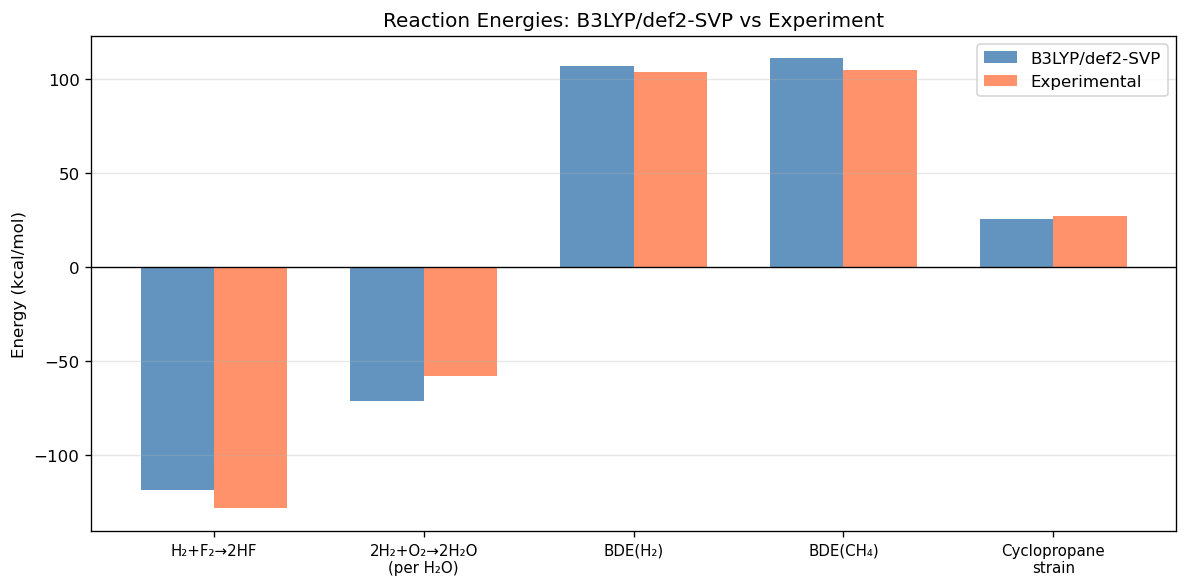

CPU times: user 25 s, sys: 818 ms, total: 25.9 s
Wall time: 6.72 s


In [15]:
%%time
# ------------------------------------------------------------------
# Isodesmic Reaction: Strain Energy of Cyclopropane
#
# C3H6 + 3 CH4 --> 3 C2H6
# Strain energy = -ΔE_isodesmic (literature: ~27.5 kcal/mol)
# ------------------------------------------------------------------

# Cyclopropane (D3h): C-C bond 1.513 A, C-H bond 1.083 A
cyc_geom = '''
C   0.000000   0.877000   0.000000
C   0.759000  -0.438500   0.000000
C  -0.759000  -0.438500   0.000000
H   0.000000   1.462000   0.904000
H   0.000000   1.462000  -0.904000
H   1.265000  -0.731000   0.904000
H   1.265000  -0.731000  -0.904000
H  -1.265000  -0.731000   0.904000
H  -1.265000  -0.731000  -0.904000
'''
_, mf_c3h6 = run_rks(cyc_geom, spin=0)

# Ethane (C2h staggered)
eth_geom = '''
C   0.000000   0.000000   0.765000
C   0.000000   0.000000  -0.765000
H   1.018000   0.000000   1.157000
H  -0.509000   0.882000   1.157000
H  -0.509000  -0.882000   1.157000
H  -1.018000   0.000000  -1.157000
H   0.509000   0.882000  -1.157000
H   0.509000  -0.882000  -1.157000
'''
_, mf_c2h6 = run_rks(eth_geom, spin=0)

dE_iso = (3*mf_c2h6.e_tot - (mf_c3h6.e_tot + 3*mf_ch4.e_tot)) * HA2KCAL
strain = -dE_iso
print('Isodesmic reaction: C₃H₆ + 3 CH₄ → 3 C₂H₆')
print(f'  ΔE_isodesmic = {dE_iso:.2f} kcal/mol')
print(f'  Strain energy = {strain:.2f} kcal/mol  (expt: ~27.5 kcal/mol)')
print(f'  Error = {strain - 27.5:.2f} kcal/mol')
print()

# ------------------------------------------------------------------
# Comparison plot
# ------------------------------------------------------------------
labels = ['H₂+F₂→2HF', '2H₂+O₂→2H₂O\n(per H₂O)', 'BDE(H₂)', 'BDE(CH₄)', 'Cyclopropane\nstrain']
computed = [dE_rxn1*HA2KCAL, dE_rxn2/2*HA2KCAL, bde_h2, bde_ch4, strain]
experimental = [-128.6, -57.8, 104.2, 105.1, 27.5]

x = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, computed, width, label='B3LYP/def2-SVP', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, experimental, width, label='Experimental', color='coral', alpha=0.85)
ax.set_ylabel('Energy (kcal/mol)')
ax.set_title('Reaction Energies: B3LYP/def2-SVP vs Experiment')
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.legend()
ax.axhline(0, color='black', linewidth=0.8)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## 🔬 Research Connection

- **Combustion chemistry**: BDEs of C–H, O–H, and N–H bonds determine fuel ignition and oxidation mechanisms. Isodesmic networks anchor computed values to ATcT (Active Thermochemical Tables).
- **Drug metabolism**: C–H BDEs in drug candidates predict sites of cytochrome P450 oxidation. A BDE < 85 kcal/mol is a flag for metabolic lability.
- **Isodesmic benchmarks**: The W4-11 and GMTKN55 datasets use thousands of isodesmic reactions to evaluate DFT methods. B3LYP/def2-TZVP achieves ~3 kcal/mol MAE on reaction energies.
- **Heats of formation**: The G4 and CBS-QB3 composite methods target < 1 kcal/mol accuracy for $\Delta H_f^\circ$, rivaling NIST experimental uncertainties.

## 📋 Summary

| Quantity | Formula | Typical DFT Error |
|---------|----------|------------------|
| $\Delta E_{rxn}$ | $\sum E_{prod} - \sum E_{react}$ | 2–5 kcal/mol (B3LYP) |
| $\Delta E_{rxn}^{ZPE}$ | $\Delta E_{rxn} + \Delta ZPE$ | 1–3 kcal/mol |
| BDE(A–B) | $E(A^\bullet) + E(B^\bullet) - E(AB)$ | 2–4 kcal/mol |
| Isodesmic $\Delta E$ | Same bond-type cancellation | < 1 kcal/mol |
| Atomization energy | $E_{mol} - \sum E_{atoms}$ | 5–20 kcal/mol (large errors) |
| Strain energy | $-\Delta E_{isodesmic}$ | 1–2 kcal/mol |

**Key insight**: Isodesmic reactions exploit systematic error cancellation; BDE calculations require unrestricted (open-shell) wavefunctions for radicals.

## 📝 Exercises

1. **Water formation**: The notebook computes $\Delta E$ for $2\text{H}_2 + \text{O}_2 \rightarrow 2\text{H}_2\text{O}$. Add a ZPE correction using approximate ZPEs (H₂: 6.2 kcal/mol, O₂: 2.3 kcal/mol, H₂O: 13.5 kcal/mol). Does agreement with experiment improve?

2. **BDE trend across halogens**: Compute BDE for HF, HCl, and HBr (use H–F: 0.917 Å, H–Cl: 1.275 Å, H–Br: 1.415 Å). Experimental BDEs: HF 136, HCl 103, HBr 87 kcal/mol. Plot computed vs experimental. What trend do you observe?

3. **Isodesmic for aromaticity**: Design an isodesmic reaction to estimate the resonance stabilization energy of benzene. One example: $\text{C}_6\text{H}_6 + 3\text{CH}_4 \rightarrow 3\text{C}_2\text{H}_4 + 3\text{C}_2\text{H}_2$ is *not* isodesmic. Find a reaction that *is* isodesmic and compute the stabilization.

4. **Basis set dependence**: Recompute BDE(H₂) with HF/STO-3G, HF/6-31G*, and B3LYP/def2-SVP. How does the basis set affect accuracy?

5. **Atomization energy**: Compute the atomization energy of CH₄ ($\text{CH}_4 \rightarrow \text{C} + 4\text{H}$). The experimental value is 398.8 kcal/mol. How does B3LYP/def2-SVP compare? Note that atomic energies require careful treatment of spin states (C: triplet, H: doublet).

---

# 09 — Population Analysis & Bonding: Charges, Bond Orders & NBO

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ppt-2/Ch121a-DFT/blob/main/notebooks/09_nbo_population_analysis.ipynb)

## 🎯 Learning Objectives
- Mulliken and Löwdin population analysis and their limitations
- Atomic partial charges with PySCF
- Wiberg bond order and interpret bond order matrices
- Natural Population Analysis (NPA) and Natural Bond Orbitals (NBO)
- Basis-set dependence of Mulliken charges
- Visualise charge distributions and compare across molecules
- Population analysis to Lewis structure and hyperconjugation concepts

## Theory: Population Analysis

### 9.1 Mulliken Population Analysis

Given the density matrix $\mathbf{P}$ and overlap matrix $\mathbf{S}$, the **Mulliken population** on atom $A$ is:

$$q_A^{\text{Mulliken}} = Z_A - \sum_{\mu \in A} (\mathbf{PS})_{\mu\mu}$$

where $Z_A$ is the nuclear charge and the sum runs over basis functions centred on $A$. This partitions overlap density equally between the two atoms — an arbitrary choice that makes Mulliken charges **strongly basis-set dependent**.

### 9.2 Löwdin Population Analysis

**Symmetric (Löwdin) orthogonalisation** transforms the basis:

$$|\tilde{\mu}\rangle = \sum_\nu (\mathbf{S}^{-1/2})_{\nu\mu} |\nu\rangle$$

The Löwdin charges use the density matrix in this orthogonal basis:

$$q_A^{\text{Löwdin}} = Z_A - \sum_{\mu \in A} \tilde{P}_{\mu\mu}, \quad \tilde{\mathbf{P}} = \mathbf{S}^{1/2}\mathbf{P}\mathbf{S}^{1/2}$$

Löwdin charges are less basis-set sensitive than Mulliken charges but still not unique.

### 9.3 Wiberg Bond Index

The **Wiberg bond order** between atoms $A$ and $B$ measures the covalent bond multiplicity:

$$B_{AB} = \sum_{\mu \in A} \sum_{\nu \in B} (\mathbf{PS})_{\mu\nu}(\mathbf{PS})_{\nu\mu}$$

| $B_{AB}$ | Interpretation |
|:--------:|----------------|
| ~1.0 | Single bond |
| ~1.5 | Aromatic / resonance |
| ~2.0 | Double bond |
| ~3.0 | Triple bond |

### 9.4 Natural Population Analysis (NPA) & NBO

**Natural Bond Orbitals** (Weinhold & Landis) provide a rigorous basis-set-independent partitioning:

1. Build **natural atomic orbitals** (NAOs) by block-diagonalising $\mathbf{P}$ in the atom-centred subspace
2. Identify **natural hybrids** (NHOs) from atom–atom block diagonalisation
3. Combine NHOs to form **NBOs**: one-centre lone pairs $n_A$ and two-centre bonds $\sigma_{AB}$
4. NPA charges: $q_A^{\text{NPA}} = Z_A - \sum_{\mu \in A} n_\mu^{\text{NAO}}$

NBO **donor–acceptor interaction energies** (hyperconjugation):

$$E^{(2)}_{\text{donor}\to\text{acceptor}} = -n_\sigma \frac{\langle \sigma | \hat{F} | \sigma^* \rangle^2}{\varepsilon_{\sigma^*} - \varepsilon_\sigma}$$

where $n_\sigma$ is the donor occupancy and $\varepsilon$ are NBO energies.
### 9.5 CHELPG / ESP Charges

**CHELPG** (Charges from Electrostatic Potentials using a Grid-based method) fits point charges to reproduce the quantum-mechanical electrostatic potential (ESP) on a grid of points around the molecule.

The objective is to minimise:

$$\sum_{k} \left[V_{\text{QM}}(\mathbf{r}_k) - \sum_i \frac{q_i}{|\mathbf{r}_k - \mathbf{R}_i|}\right]^2$$

subject to the constraint $\sum_i q_i = Q_{\text{total}}$, where $V_{\text{QM}}(\mathbf{r}_k)$ is the QM ESP at grid point $k$, and $q_i$ are the fitted atomic charges.

**Key properties:**
- Grid points are placed on shells between 1.4× and 2.8× the atomic van der Waals radii, excluding points inside the molecule.
- **Less basis-set dependent** than Mulliken charges, since the ESP in chemically relevant regions (outside the molecule) is relatively insensitive to the choice of basis.
- **Preferred for force-field parameterisation** (RESP = Restrained ESP charges; used in AMBER, CHARMM, OPLS).
- Implemented in PySCF via a direct grid evaluation: compute $V_{\text{QM}}$ using `mol.intor('int1e_rinv')` at each grid point, then solve the constrained least-squares problem.

In [26]:
%%time
# =============================================================================
# Ch121a: Quantum Chemistry & DFT — Notebook 09: Population Analysis
# License: GPL-3.0 (https://www.gnu.org/licenses/gpl-3.0.en.html)
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
import matplotlib.pyplot as plt
from pyscf import gto, dft, scf
from pyscf.lo import orth

def run_rks(atom_str, basis='def2-SVP', xc='B3LYP', verbose=0):
    mol = gto.Mole(atom=atom_str, basis=basis, verbose=verbose)
    mol.build()
    mf = dft.RKS(mol)
    mf.xc = xc
    mf.verbose = verbose
    mf.kernel()
    return mol, mf

def mulliken_charges(mol, mf):
    """Compute Mulliken charges from density and overlap matrices."""
    dm   = mf.make_rdm1()            # AO density matrix
    S    = mol.intor('int1e_ovlp')   # overlap matrix
    PS   = dm @ S                    # P * S product
    pop  = np.einsum('ii->i', PS)    # diagonal: population per AO
    # Sum over AOs on each atom
    charges = np.array([mol.atom_charge(i) for i in range(mol.natm)], dtype=float)
    for i, (ao_start, ao_end) in enumerate(zip(*mol.aoslice_by_atom()[:, 2:].T)):
        charges[i] -= pop[ao_start:ao_end].sum()
    # Re-do using pyscf built-in for clarity
    pop_mull, chg_mull = mf.mulliken_pop(verbose=0)
    return chg_mull

def lowdin_charges(mol, mf):
    """Compute Löwdin charges via symmetric orthogonalisation."""
    dm = mf.make_rdm1()
    S  = mol.intor('int1e_ovlp')
    # S^(1/2) via eigen-decomposition
    eigvals, eigvecs = np.linalg.eigh(S)
    S_half = eigvecs @ np.diag(np.sqrt(eigvals)) @ eigvecs.T
    # Löwdin density matrix: P_tilde = S^(1/2) P S^(1/2)
    P_tilde = S_half @ dm @ S_half
    pop_lowdin = np.einsum('ii->i', P_tilde)
    charges = np.array([mol.atom_charge(i) for i in range(mol.natm)], dtype=float)
    atom_slices = mol.aoslice_by_atom()
    for i in range(mol.natm):
        ao_s, ao_e = atom_slices[i, 2], atom_slices[i, 3]
        charges[i] -= pop_lowdin[ao_s:ao_e].sum()
    return charges


def compute_esp_charges(mol, dm, n_shells=5, density=2.5):
    """
    Compute CHELPG-style ESP charges by fitting point charges to the
    electrostatic potential on a grid of points outside the VdW surface.

    Parameters
    ----------
    mol      : PySCF Mole object (already built)
    dm       : density matrix from mf.make_rdm1()
    n_shells : number of radial shells for ESP grid
    density  : grid point density (points/Angstrom^2) per shell

    Returns
    -------
    charges : ndarray of shape (natm,)
    """
    from pyscf.data.nist import BOHR

    # Bondi VdW radii in Angstrom
    vdw_radii = {'H': 1.20, 'C': 1.70, 'N': 1.55, 'O': 1.52, 'F': 1.47,
                 'S': 1.80, 'Cl': 1.75, 'B': 1.92, 'P': 1.80}

    coords = mol.atom_coords() * BOHR          # convert Bohr -> Angstrom
    atoms  = [mol.atom_symbol(i) for i in range(mol.natm)]
    radii  = np.array([vdw_radii.get(a, 1.70) for a in atoms])

    # Build grid: shells from 1.4x to (1.4 + (n_shells-1)*0.2)x VdW radius
    grid_pts = []
    for shell in range(n_shells):
        scale = 1.4 + shell * 0.2
        for i, (center, r) in enumerate(zip(coords, radii)):
            R = scale * r
            n_pts = max(12, int(density * 4 * np.pi * R**2))
            # Fibonacci lattice on sphere
            golden = (1 + np.sqrt(5)) / 2
            idx = np.arange(n_pts)
            theta = np.arccos(1 - 2 * (idx + 0.5) / n_pts)
            phi   = 2 * np.pi * idx / golden
            pts = center + R * np.column_stack([
                np.sin(theta) * np.cos(phi),
                np.sin(theta) * np.sin(phi),
                np.cos(theta)
            ])
            # Keep only points outside ALL VdW spheres
            dists   = np.linalg.norm(pts[:, None, :] - coords[None, :, :], axis=2)
            outside = ~(dists < radii[None, :]).any(axis=1)
            grid_pts.append(pts[outside])

    grid_pts  = np.vstack(grid_pts)       # (N_grid, 3) Angstrom
    grid_bohr = grid_pts / BOHR           # (N_grid, 3) Bohr

    # --- Nuclear ESP contribution ---
    V_nuc = np.zeros(len(grid_bohr))
    for i in range(mol.natm):
        r_nuc = mol.atom_coord(i)          # Bohr
        Z     = mol.atom_charge(i)
        diff  = grid_bohr - r_nuc[None, :]
        V_nuc += Z / np.linalg.norm(diff, axis=1)

    # --- Electronic ESP contribution: V_elec = -Tr(P * <mu|1/r|nu>) ---
    V_elec = np.zeros(len(grid_bohr))
    for k, rk in enumerate(grid_bohr):
        with mol.with_rinv_origin(rk):
            rinv = mol.intor('int1e_rinv')
        V_elec[k] = -np.einsum('ij,ij->', dm, rinv)

    V_qm = V_nuc + V_elec   # total ESP (atomic units)

    # --- Constrained least-squares fit: sum(q) = mol.charge ---
    A = np.zeros((len(grid_bohr), mol.natm))
    for i in range(mol.natm):
        r_nuc = mol.atom_coord(i)
        diff  = grid_bohr - r_nuc[None, :]
        A[:, i] = 1.0 / np.linalg.norm(diff, axis=1)

    # Augment with charge-conservation constraint row
    B = np.vstack([A, np.ones((1, mol.natm))])
    b = np.append(V_qm, float(mol.charge))
    charges, _, _, _ = np.linalg.lstsq(B, b, rcond=None)
    return charges

# ------------------------------------------------------------------
# H2O charges
# ------------------------------------------------------------------
water_geom = 'O 0 0 0.117; H 0  0.757 -0.469; H 0 -0.757 -0.469'
mol_h2o, mf_h2o = run_rks(water_geom)

mull_h2o  = mulliken_charges(mol_h2o, mf_h2o)
lowdin_h2o = lowdin_charges(mol_h2o, mf_h2o)

dm_h2o     = mf_h2o.make_rdm1()
chelpg_h2o = compute_esp_charges(mol_h2o, dm_h2o)

print('Water (H₂O) — B3LYP/def2-SVP')
print('=' * 60)
print(f'  Atom   Mulliken   Löwdin    CHELPG')
for i in range(mol_h2o.natm):
    sym = mol_h2o.atom_symbol(i)
    print(f'  {sym:5s}   {mull_h2o[i]:+.4f}     {lowdin_h2o[i]:+.4f}    {chelpg_h2o[i]:+.4f}')
print(f'  Sum    {sum(mull_h2o):+.4f}     {sum(lowdin_h2o):+.4f}    {sum(chelpg_h2o):+.4f}  (should be 0)')

Water (H₂O) — B3LYP/def2-SVP
  Atom   Mulliken   Löwdin    CHELPG
  O       -0.2897     -0.1408    -0.7189
  H       +0.1448     +0.0704    +0.3586
  H       +0.1448     +0.0704    +0.3600
  Sum    -0.0000     -0.0000    -0.0003  (should be 0)
CPU times: user 6.72 s, sys: 5.05 ms, total: 6.72 s
Wall time: 1.75 s


In [27]:
%%time
# ------------------------------------------------------------------
# Charges for NH3, BH3, BF3 — comparison across molecules
# ------------------------------------------------------------------

molecules = {
    'NH₃': 'N 0 0 0.116; H 0  0.939 -0.269; H  0.813 -0.469 -0.269; H -0.813 -0.469 -0.269',
    'BH₃': 'B 0 0 0; H 1.189 0 0; H -0.595  1.030 0; H -0.595 -1.030 0',
    'BF₃': 'B 0 0 0; F 1.307 0 0; F -0.654  1.132 0; F -0.654 -1.132 0',
}

results = []
for mol_name, geom in molecules.items():
    mol, mf = run_rks(geom)
    mull   = mulliken_charges(mol, mf)
    lowdin = lowdin_charges(mol, mf)
    chelpg = compute_esp_charges(mol, mf.make_rdm1())
    # Record central atom and first substituent charges
    results.append({
        'Molecule': mol_name,
        'Central atom': mol.atom_symbol(0),
        'Mulliken (central)': round(mull[0], 3),
        'Löwdin (central)': round(lowdin[0], 3),
        'CHELPG (central)': round(chelpg[0], 3),
        'Mulliken (H/F)': round(mull[1], 3),
        'Löwdin (H/F)': round(lowdin[1], 3),
        'CHELPG (H/F)': round(chelpg[1], 3),
    })
    print(f'{mol_name}:')
    for i in range(mol.natm):
        print(f'  {mol.atom_symbol(i):4s}  Mulliken {mull[i]:+.3f}   Löwdin {lowdin[i]:+.3f}   CHELPG {chelpg[i]:+.3f}')
    print()

df_charges = pd.DataFrame(results)
print('Summary:')
print(df_charges.to_string(index=False))

NH₃:
  N     Mulliken -0.241   Löwdin -0.153   CHELPG -0.930
  H     Mulliken +0.080   Löwdin +0.051   CHELPG +0.311
  H     Mulliken +0.080   Löwdin +0.051   CHELPG +0.311
  H     Mulliken +0.080   Löwdin +0.051   CHELPG +0.311

BH₃:
  B     Mulliken +0.047   Löwdin +0.098   CHELPG +0.542
  H     Mulliken -0.016   Löwdin -0.033   CHELPG -0.181
  H     Mulliken -0.016   Löwdin -0.033   CHELPG -0.181
  H     Mulliken -0.016   Löwdin -0.033   CHELPG -0.181

BF₃:
  B     Mulliken +0.260   Löwdin -0.206   CHELPG +0.927
  F     Mulliken -0.086   Löwdin +0.069   CHELPG -0.309
  F     Mulliken -0.087   Löwdin +0.069   CHELPG -0.309
  F     Mulliken -0.087   Löwdin +0.069   CHELPG -0.309

Summary:
Molecule Central atom  Mulliken (central)  Löwdin (central)  CHELPG (central)  Mulliken (H/F)  Löwdin (H/F)  CHELPG (H/F)
     NH₃            N              -0.241            -0.153            -0.930           0.080         0.051         0.311
     BH₃            B               0.047             0.0

Basis-set dependence of O charge in H₂O (B3LYP):
  Basis           Mulliken (O)    Löwdin (O)    CHELPG (O)
  STO-3G               -0.3686       -0.2539       -0.6034
  3-21G                -0.6563       -0.4280       -0.8121
  6-31G*               -0.7978       -0.6158       -0.7546
  def2-SVP             -0.2897       -0.1408       -0.7189
  def2-TZVP            -0.6275       -0.3047       -0.7488
  def2-QZVP            -0.3989       +0.7272       -0.6926


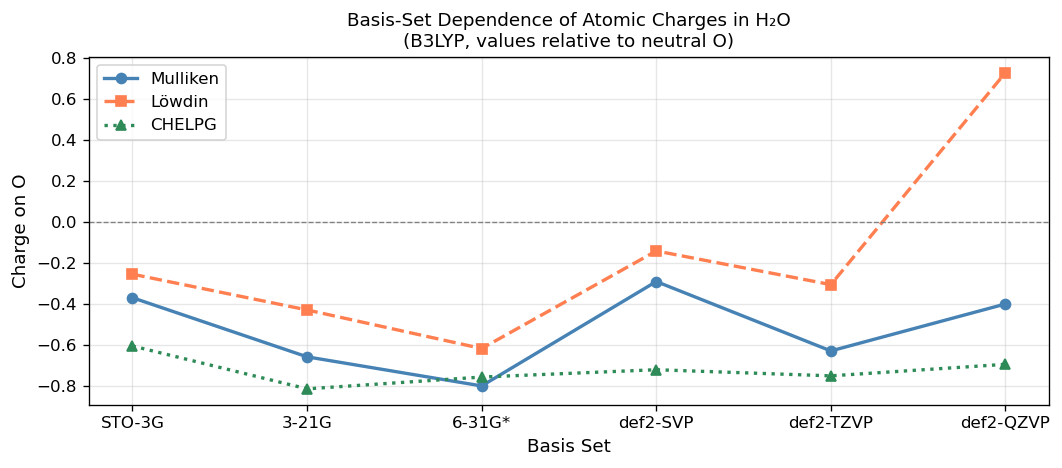


Key observation:
Mulliken charges vary wildly with basis set (especially large bases).
Löwdin charges are more stable but still basis-dependent.
CHELPG charges are much less basis-set sensitive, since the ESP in the
chemically relevant region (outside the molecule) converges quickly.
NPA charges (from NBO analysis) are the most basis-set independent.


In [28]:
# ------------------------------------------------------------------
# Basis-Set Dependence of Mulliken Charges for H2O
# ------------------------------------------------------------------
bases = ['STO-3G', '3-21G', '6-31G*', 'def2-SVP', 'def2-TZVP', 'def2-QZVP']
o_charges_mull   = []
o_charges_lowdin = []
o_charges_chelpg = []

for basis in bases:
    try:
        mol, mf = run_rks(water_geom, basis=basis)
        mull   = mulliken_charges(mol, mf)
        lowdin = lowdin_charges(mol, mf)
        chelpg = compute_esp_charges(mol, mf.make_rdm1())
        o_charges_mull.append(mull[0])
        o_charges_lowdin.append(lowdin[0])
        o_charges_chelpg.append(chelpg[0])
    except Exception as e:
        o_charges_mull.append(float('nan'))
        o_charges_lowdin.append(float('nan'))
        o_charges_chelpg.append(float('nan'))

print('Basis-set dependence of O charge in H₂O (B3LYP):')
print(f"  {'Basis':12s}  {'Mulliken (O)':>14s}  {'Löwdin (O)':>12s}  {'CHELPG (O)':>12s}")
for b, m, l, c in zip(bases, o_charges_mull, o_charges_lowdin, o_charges_chelpg):
    print(f'  {b:12s}  {m:+14.4f}  {l:+12.4f}  {c:+12.4f}')

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(bases, o_charges_mull,   'o-',  color='steelblue', lw=2, label='Mulliken')
ax.plot(bases, o_charges_lowdin, 's--', color='coral',     lw=2, label='Löwdin')
ax.plot(bases, o_charges_chelpg, '^:',  color='seagreen',  lw=2, label='CHELPG')
ax.set_xlabel('Basis Set', fontsize=11)
ax.set_ylabel('Charge on O', fontsize=11)
ax.set_title('Basis-Set Dependence of Atomic Charges in H₂O\n(B3LYP, values relative to neutral O)', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.axhline(0, color='gray', lw=0.8, ls='--')
plt.tight_layout()
plt.show()

print('\nKey observation:')
print('Mulliken charges vary wildly with basis set (especially large bases).')
print('Löwdin charges are more stable but still basis-dependent.')
print('CHELPG charges are much less basis-set sensitive, since the ESP in the')
print('chemically relevant region (outside the molecule) converges quickly.')
print('NPA charges (from NBO analysis) are the most basis-set independent.')

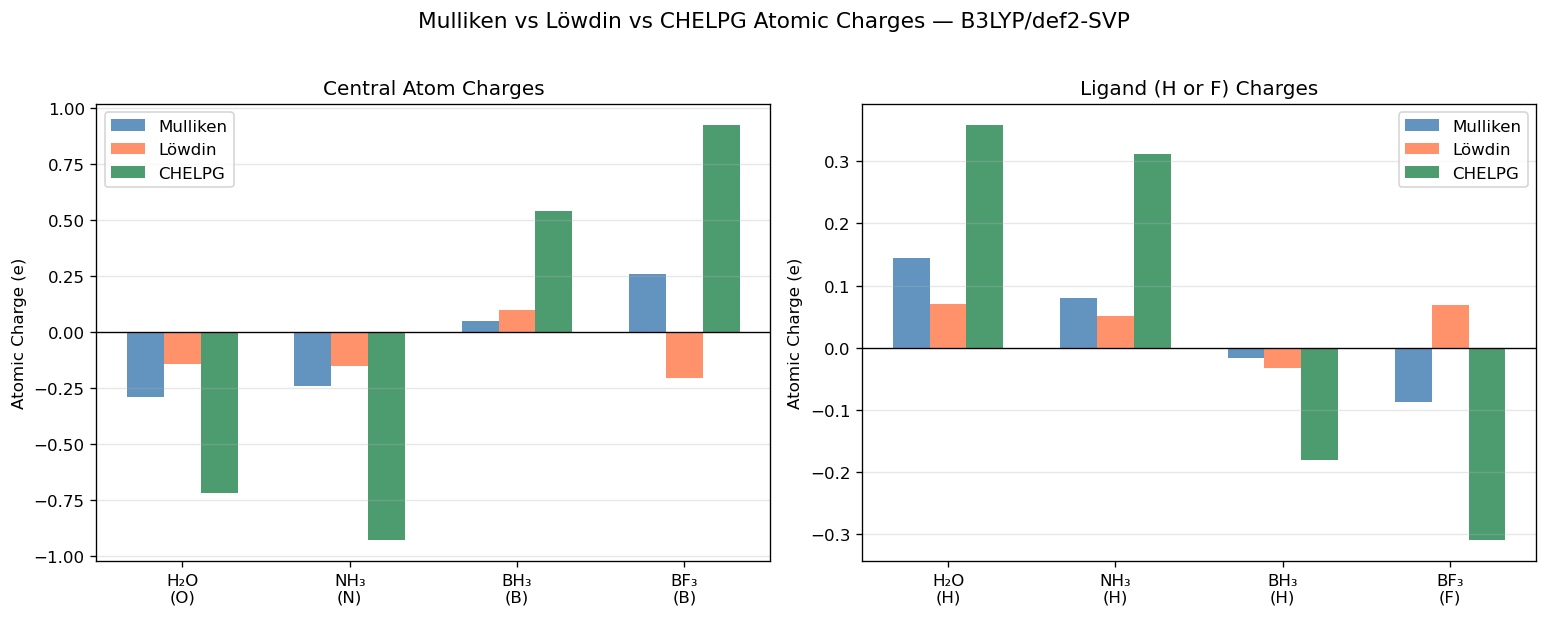

Trends to note:
  H₂O: O is strongly negative (high electronegativity)
  NH₃: N is negative (lone pair donor); H slightly positive
  BH₃: B slightly positive; H slightly negative (H more electronegative than expected)
  BF₃: B strongly positive; F strongly negative (high electronegativity of F)


In [29]:
# ------------------------------------------------------------------
# Charge Comparison Bar Chart across H2O, NH3, BH3, BF3
# ------------------------------------------------------------------
import matplotlib.pyplot as plt
import numpy as np

mol_names = ['H₂O', 'NH₃', 'BH₃', 'BF₃']
central_atoms = ['O', 'N', 'B', 'B']

# Collect central-atom Mulliken, Löwdin, and CHELPG charges
mull_central   = []
low_central    = []
chelpg_central = []
mull_ligand    = []
low_ligand     = []
chelpg_ligand  = []

for mol_name, geom in [('H₂O', water_geom), ('NH₃', molecules['NH₃']),
                        ('BH₃', molecules['BH₃']), ('BF₃', molecules['BF₃'])]:
    if mol_name == 'H₂O':
        mol, mf = mol_h2o, mf_h2o
    else:
        mol, mf = run_rks(molecules[mol_name])
    mull   = mulliken_charges(mol, mf)
    lowdin = lowdin_charges(mol, mf)
    chelpg = compute_esp_charges(mol, mf.make_rdm1())
    mull_central.append(mull[0])
    low_central.append(lowdin[0])
    chelpg_central.append(chelpg[0])
    mull_ligand.append(mull[1])
    low_ligand.append(lowdin[1])
    chelpg_ligand.append(chelpg[1])

x = np.arange(len(mol_names))
width = 0.22

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Central atom
bars1 = ax1.bar(x - width, mull_central,   width, label='Mulliken', color='steelblue', alpha=0.85)
bars2 = ax1.bar(x,         low_central,    width, label='Löwdin',   color='coral',     alpha=0.85)
bars3 = ax1.bar(x + width, chelpg_central, width, label='CHELPG',   color='seagreen',  alpha=0.85)
ax1.set_xticks(x); ax1.set_xticklabels([f'{n}\n({a})' for n,a in zip(mol_names, central_atoms)])
ax1.set_ylabel('Atomic Charge (e)')
ax1.set_title('Central Atom Charges')
ax1.legend(); ax1.axhline(0, color='black', lw=0.8); ax1.grid(True, alpha=0.3, axis='y')

# Ligand (H or F)
ligand_names = ['H', 'H', 'H', 'F']
bars4 = ax2.bar(x - width, mull_ligand,   width, label='Mulliken', color='steelblue', alpha=0.85)
bars5 = ax2.bar(x,         low_ligand,    width, label='Löwdin',   color='coral',     alpha=0.85)
bars6 = ax2.bar(x + width, chelpg_ligand, width, label='CHELPG',   color='seagreen',  alpha=0.85)
ax2.set_xticks(x); ax2.set_xticklabels([f'{n}\n({l})' for n,l in zip(mol_names, ligand_names)])
ax2.set_ylabel('Atomic Charge (e)')
ax2.set_title('Ligand (H or F) Charges')
ax2.legend(); ax2.axhline(0, color='black', lw=0.8); ax2.grid(True, alpha=0.3, axis='y')

plt.suptitle('Mulliken vs Löwdin vs CHELPG Atomic Charges — B3LYP/def2-SVP', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('Trends to note:')
print('  H₂O: O is strongly negative (high electronegativity)')
print('  NH₃: N is negative (lone pair donor); H slightly positive')
print('  BH₃: B slightly positive; H slightly negative (H more electronegative than expected)')
print('  BF₃: B strongly positive; F strongly negative (high electronegativity of F)')

## 9.x. Natural Bond Orbital (NBO) Analysis — Overview

PySCF provides localised orbital tools in `pyscf.lo`. Full NBO analysis (as in the Weinhold NBO program) requires an external interface, but natural atomic orbitals (NAOs) and intrinsic bond orbitals (IBOs) can be constructed:

```python
from pyscf.lo import orth, nao

# Natural Atomic Orbitals for H2O
mol, mf = run_rks('O 0 0 0.117; H 0 0.757 -0.469; H 0 -0.757 -0.469')

# NAO coefficients (C_nao) — unitary rotation of AO basis
C_nao = nao.nao_nr(mol, mf)   # shape: (nao, nmo)

# NPA charges from NAO occupancies
dm_nao = C_nao.T @ mf.make_rdm1() @ C_nao  # density matrix in NAO basis
nao_occ = np.diag(dm_nao)                   # diagonal = occupancy

# NPA charge on each atom
npa_charges = np.array([mol.atom_charge(i) for i in range(mol.natm)], dtype=float)
for i, (s, e) in enumerate(zip(*mol.aoslice_by_atom()[:, 2:].T)):
    npa_charges[i] -= nao_occ[s:e].sum()
```

**Donor–acceptor hyperconjugation** (requires full NBO program):
- In ethane: $\sigma_{\text{CH}} \to \sigma^*_{\text{CH}}$ interactions stabilise the staggered conformation
- In vinyl fluoride: F lone pair $\to \pi^*_{\text{C=C}}$ delocalisation shortens the C–F bond
- In BF₃: empty B $p_z \to$ F lone pair back-donation gives partial $\pi$ character to B–F

These interactions are quantified by $E^{(2)}$ energies, available from NBO 6/7 or JANPA.

## 🔬 Research Connection

Population analysis is ubiquitous in computational chemistry:

- **Reactivity prediction**: Atoms with high NPA charges are nucleophilic or electrophilic reaction sites. Fukui functions (HOMO/LUMO density) refine this.
- **Force field development**: RESP (Restrained Electrostatic Potential) charges are fit to reproduce the QM electrostatic potential — used in AMBER, CHARMM, and OPLS force fields.
- **Hydrogen bonding**: The charge on the H-bond donor hydrogen (typically +0.3 to +0.5 $e$ from NPA) correlates strongly with H-bond strength.
- **Hyperconjugation in drug molecules**: NBO analysis reveals anomeric effects in carbohydrates, rotational barriers in amides (peptide bond), and conformational preferences in drug-like molecules.
- **Charge-transfer complexes**: The NPA charge transferred in donor–acceptor complexes quantifies the degree of charge-transfer character.

## 📋 Summary

| Method | Formula | Basis Sensitivity | Typical Use |
|--------|---------|:-----------------:|-------------|
| Mulliken | $(\mathbf{PS})_{\mu\mu}$ sum per atom | Very high ✗ | Quick checks, small basis |
| Löwdin | $(\mathbf{S}^{1/2}\mathbf{P}\mathbf{S}^{1/2})_{\mu\mu}$ | Moderate | Better than Mulliken |
| NPA (NBO) | NAO density per atom | Low ✓ | Publication quality |
| RESP | Fit to ESP grid | Low ✓ | Force field parametrisation |
| Wiberg BO | $\sum_{\mu\nu}(\mathbf{PS})_{\mu\nu}^2$ | Moderate | Bond multiplicity |

**Recommendation**: Always use NPA/NBO charges for publication; report Mulliken charges only for quick comparisons within the same basis set.

## 📝 Exercises

1. **Electronegativity trend**: Compute Mulliken and Löwdin charges on the central atom in CH₄, NH₃, H₂O, and HF at B3LYP/def2-SVP. Plot the central atom charge vs Pauling electronegativity (C: 2.55, N: 3.04, O: 3.44, F: 3.98). Is the correlation linear?

2. **Basis-set sensitivity**: Recompute the Mulliken charge on N in NH₃ using STO-3G, 3-21G, 6-31G*, def2-SVP, and def2-TZVP. How does the charge change? Is Löwdin more stable?

3. **Bond order vs bond length**: Compute Wiberg bond orders for N₂ (triple bond, 1.098 Å), N₂H₄ (single N–N, 1.449 Å), and N₂H₂ (double N=N, 1.252 Å). Do the computed bond orders follow the expected trend 3 > 2 > 1?

4. **Hyperconjugation in BF₃**: The B–F bond length in BF₃ (1.307 Å) is shorter than a typical B–F single bond (~1.39 Å), suggesting partial double-bond character due to F $p_z \to$ B $p_z$ back-donation. Compute the Wiberg B–F bond order and compare with BH₃ B–H bond order. Does the data support $\pi$ back-donation?

5. **Charge vs dipole moment**: Using the Mulliken charges from this notebook, estimate the dipole moment of H₂O as $\mu \approx \sum_i q_i \mathbf{r}_i$. Compare with the DFT dipole moment from `mf.dip_moment()`. Discuss why they differ.

---

# 10 — Solvation Effects: PCM, COSMO & pKa Prediction

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ppt-2/Ch121a-DFT/blob/main/notebooks/11_solvation_effects.ipynb)

## 🎯 Learning Objectives

- Implicit solvation models (PCM, COSMO, SMD)
- ddCOSMO solvation calculations with PySCF
- Solvation free energies ΔG_solv for small molecules
- pKa using a thermodynamic cycle
- How the dielectric constant controls solvation strength
- When to use explicit vs implicit solvation

## Theory: Implicit Solvation Models

### 10.1 Born Model (Spherical Cavity)

The simplest model places charge $q$ in a spherical cavity of radius $a$ in a dielectric
of permittivity $\varepsilon$:

$$\Delta G_{\rm Born} = -\frac{q^2}{2a}\left(1 - \frac{1}{\varepsilon}\right)$$

For water ($\varepsilon \approx 78.4$), $\Delta G_{\rm Born}$ captures most ionic solvation
energy but neglects molecular shape effects.

### 10.2 Polarizable Continuum Model (PCM)

PCM builds a **molecular-shaped cavity** (van der Waals or solvent-excluding surface)
and places apparent surface charges $\sigma(\mathbf{s})$ at the boundary to screen the
solute's electric field:

$$V_{\rm react}(\mathbf{r}) = \int_{\partial\Omega}
  \frac{\sigma(\mathbf{s})}{|\mathbf{r}-\mathbf{s}|}\,d\mathbf{s}$$

The solute Hamiltonian becomes $\hat{H} = \hat{H}_0 + \hat{V}_{\rm react}$, solved
self-consistently.

### 10.3 COSMO and ddCOSMO

**COSMO** approximates the solvent as a conductor ($\varepsilon\to\infty$) then rescales:

$$q^* = -\frac{\varepsilon-1}{\varepsilon+0.5}\,q_{\rm conductor}$$

PySCF implements **ddCOSMO** (domain-decomposition COSMO), which scales as $O(N)$
with system size.

### 10.4 Thermodynamic Cycle for pKa

$$\mathrm{HA_{(aq)}} \rightleftharpoons \mathrm{H^+_{(aq)}} + \mathrm{A^-_{(aq)}}$$

$$\Delta G_{\rm aq}^{\rm deprot} = \Delta G_{\rm gas}^{\rm deprot}
  + \Delta G_{\rm solv}(A^-) + \Delta G_{\rm solv}(H^+)
  - \Delta G_{\rm solv}(HA)$$

$$\mathrm{p}K_a = \frac{\Delta G_{\rm aq}^{\rm deprot}}{RT\ln 10}$$

where $\Delta G_{\rm solv}(H^+) = -265.9$ kcal/mol (experimental absolute proton solvation).

In [22]:
%%time
# =============================================================================
# Ch121a: Quantum Chemistry & DFT — Notebook 11: Solvation Effects
# License: GPL-3.0 (https://www.gnu.org/licenses/gpl-3.0.en.html)
# =============================================================================
import numpy as np
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
import matplotlib.pyplot as plt
from pyscf import gto, dft, solvent

HARTREE2KCAL = 627.5095

def run_dft_gas(atom_str, basis='def2-SVP', xc='b3lyp', charge=0, spin=0):
    mol = gto.M(atom=atom_str, basis=basis, charge=charge, spin=spin, verbose=0)
    mf = dft.RKS(mol); mf.xc = xc
    mf.kernel()
    return mf.e_tot

def run_ddcosmo(atom_str, basis='def2-SVP', xc='b3lyp', eps=78.4, charge=0, spin=0):
    mol = gto.M(atom=atom_str, basis=basis, charge=charge, spin=spin, verbose=0)
    mf_base = dft.RKS(mol); mf_base.xc = xc
    mf_solv = solvent.ddCOSMO(mf_base)
    mf_solv.with_solvent.eps = eps
    mf_solv.kernel()
    return mf_solv.e_tot

# ------------------------------------------------------------------
# Solvation Free Energies in Water (ε = 78.4)
# ------------------------------------------------------------------
molecules = {
    'H2O':   'O 0 0 0.117; H 0 0.757 -0.469; H 0 -0.757 -0.469',
    'NH3':   'N 0 0 0.116; H 0 0.939 -0.271; H 0.813 -0.470 -0.271; H -0.813 -0.470 -0.271',
    'HF':    'H 0 0 0; F 0 0 0.917',
    'CH3OH': 'C 0 0 0; O 1.43 0 0; H -0.36 0.89 0; H -0.36 -0.89 0; H -0.36 0 0.89; H 1.85 0.96 0',
}

print(f"{'Molecule':>8}  {'E_gas (Eh)':>14}  {'E_solv (Eh)':>14}  {'ΔG_solv (kcal/mol)':>20}")
print("-" * 62)
dG_results = {}
for name, atom in molecules.items():
    e_gas = run_dft_gas(atom)
    e_solv = run_ddcosmo(atom)
    dG = (e_solv - e_gas) * HARTREE2KCAL
    dG_results[name] = dG
    print(f"{name:>8}  {e_gas:14.6f}  {e_solv:14.6f}  {dG:20.2f}")

Molecule      E_gas (Eh)     E_solv (Eh)    ΔG_solv (kcal/mol)
--------------------------------------------------------------
     H2O      -76.358125      -76.364681                 -4.11
     NH3      -56.509328      -56.514258                 -3.09
      HF     -100.353159     -100.358478                 -3.34
   CH3OH     -115.508627     -115.515173                 -4.11
CPU times: user 1min 4s, sys: 741 ms, total: 1min 5s
Wall time: 16.9 s


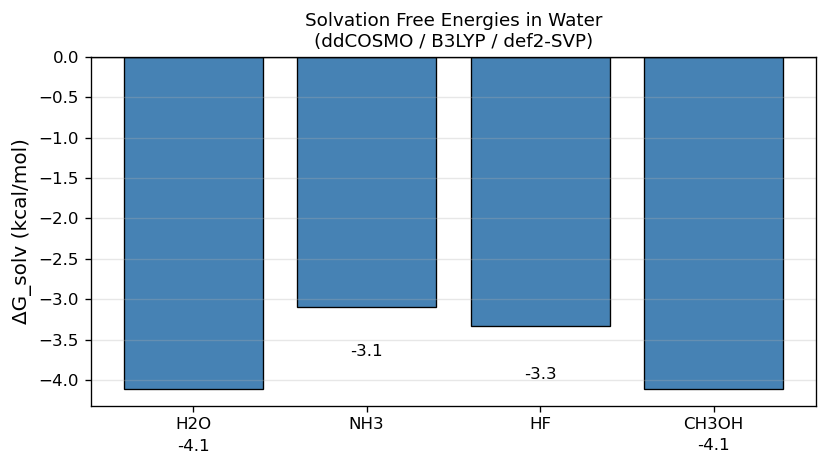

In [23]:
# ------------------------------------------------------------------
# Bar Chart: Solvation Energies
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 4))
names = list(dG_results.keys())
vals = [dG_results[n] for n in names]
colors = ['steelblue' if v < 0 else 'coral' for v in vals]
bars = ax.bar(names, vals, color=colors, edgecolor='black', linewidth=0.8)
ax.axhline(0, color='black', linewidth=0.8)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, val - 0.15 * abs(val),
            f'{val:.1f}', ha='center', va='top', fontsize=10)
ax.set_ylabel('ΔG_solv (kcal/mol)', fontsize=12)
ax.set_title('Solvation Free Energies in Water\n(ddCOSMO / B3LYP / def2-SVP)', fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

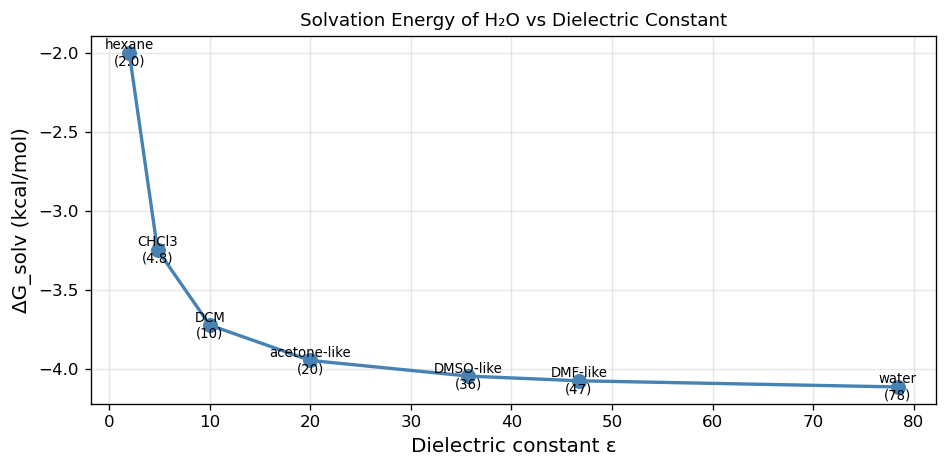

CPU times: user 51.8 s, sys: 43.5 ms, total: 51.8 s
Wall time: 13.4 s


In [24]:
%%time
# ------------------------------------------------------------------
# Effect of Dielectric Constant on Solvation Energy of H2O
# ------------------------------------------------------------------
water_atom = 'O 0 0 0.117; H 0 0.757 -0.469; H 0 -0.757 -0.469'
e_gas_w = run_dft_gas(water_atom)

eps_vals = [2.0, 4.81, 10.0, 20.0, 35.7, 46.7, 78.4]
labels   = ['hexane\n(2.0)', 'CHCl3\n(4.8)', 'DCM\n(10)', 'acetone-like\n(20)',
            'DMSO-like\n(36)', 'DMF-like\n(47)', 'water\n(78)']
dG_eps = []
for eps in eps_vals:
    e_s = run_ddcosmo(water_atom, eps=eps)
    dG_eps.append((e_s - e_gas_w) * HARTREE2KCAL)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(eps_vals, dG_eps, 'o-', color='steelblue', linewidth=2, markersize=8)
for x, y, lbl in zip(eps_vals, dG_eps, labels):
    ax.annotate(lbl, xy=(x, y), xytext=(x, y - 0.08), fontsize=8, ha='center')
ax.set_xlabel('Dielectric constant ε', fontsize=12)
ax.set_ylabel('ΔG_solv (kcal/mol)', fontsize=12)
ax.set_title('Solvation Energy of H₂O vs Dielectric Constant', fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [25]:
%%time
# ------------------------------------------------------------------
# Approximate pKa of Acetic Acid via Thermodynamic Cycle
# ------------------------------------------------------------------
# ΔG_solv(H+) = -265.9 kcal/mol (Tissandier et al., experimental)
DG_SOLV_HPLUS = -265.9

HA = 'C -0.56 0 0; C 0.56 0 0; O 1.19 1.07 0; O 1.19 -1.07 0; H -0.56 1.03 0; H -0.56 -1.03 0; H -1.59 0 0'
A  = 'C -0.56 0 0; C 0.56 0 0; O 1.19 1.07 0; O 1.19 -1.07 0; H -0.56 1.03 0; H -0.56 -1.03 0; H -1.59 0 0'

# Use a simpler acetic acid geometry
HA_atom = 'C 0 0 0; O 0 1.22 0; O 1.34 -0.04 0; H 1.67 0.82 0; H -1.02 0 0; H 0.27 0 1.03; H 0.27 0 -1.03'
A_atom  = 'C 0 0 0; O 0 1.25 0; O 1.25 0 0; H -1.02 0 0; H 0.27 0 1.03; H 0.27 0 -1.03'

e_HA_gas = run_dft_gas(HA_atom, charge=0)
e_A_gas  = run_dft_gas(A_atom, charge=-1)
e_H_gas  = 0.0  # proton has no electrons; nuclear repulsion = 0 for bare H+

dG_gas = (e_A_gas + e_H_gas - e_HA_gas) * HARTREE2KCAL

e_HA_solv = run_ddcosmo(HA_atom, charge=0)
e_A_solv  = run_ddcosmo(A_atom, charge=-1)
dG_solv_HA = (e_HA_solv - e_HA_gas) * HARTREE2KCAL
dG_solv_A  = (e_A_solv - e_A_gas) * HARTREE2KCAL

dG_aq = dG_gas + dG_solv_A + DG_SOLV_HPLUS - dG_solv_HA
RT_ln10 = 1.987e-3 * 298.15 * np.log(10)
pKa = dG_aq / RT_ln10

print("Acetic acid pKa (B3LYP/def2-SVP + ddCOSMO):")
print(f"  ΔG_gas (deprot)  = {dG_gas:+8.1f} kcal/mol")
print(f"  ΔG_solv(HA)      = {dG_solv_HA:+8.2f} kcal/mol")
print(f"  ΔG_solv(A⁻)      = {dG_solv_A:+8.2f} kcal/mol")
print(f"  ΔG_solv(H⁺) exp  = {DG_SOLV_HPLUS:+8.1f} kcal/mol")
print(f"  ΔG_aq (deprot)   = {dG_aq:+8.1f} kcal/mol")
print(f"  Computed pKa     = {pKa:.1f}  (experimental: 4.76)")
print("\nNote: Errors arise from geometry approximations and missing")
print("thermal corrections. Systematic pKa protocols reduce error to ~0.5 units.")

Acetic acid pKa (B3LYP/def2-SVP + ddCOSMO):
  ΔG_gas (deprot)  =   +392.8 kcal/mol
  ΔG_solv(HA)      =    -6.16 kcal/mol
  ΔG_solv(A⁻)      =   -65.70 kcal/mol
  ΔG_solv(H⁺) exp  =   -265.9 kcal/mol
  ΔG_aq (deprot)   =    +67.4 kcal/mol
  Computed pKa     = 49.4  (experimental: 4.76)

Note: Errors arise from geometry approximations and missing
thermal corrections. Systematic pKa protocols reduce error to ~0.5 units.
CPU times: user 1min 14s, sys: 3.31 s, total: 1min 18s
Wall time: 20.3 s


## 10.X. Explicit vs Implicit Solvation

| Model | Pros | Cons |
|-------|------|------|
| **Implicit (PCM/COSMO)** | Fast; no conformational sampling | No H-bonds; poor for multiply charged anions |
| **Explicit (QM/MM)** | Correct first-shell structure | Needs MD sampling; expensive |
| **Cluster + PCM** | First-shell explicit + bulk dielectric | Need cluster size convergence test |

**Rule of thumb**: Add 1–4 explicit water molecules for charged species before applying PCM.

## 🔬 Research Connection

Solvation models are central to computational chemistry and drug discovery:

- **Log P and solubility**: Aqueous and lipid solvation free energies predict partition
  coefficients (log P), a key pharmacokinetic descriptor.
- **pKa prediction**: Accurate pKa values guide ionisation state assignment in protein
  active sites and ADMET property prediction.
- **Electrochemistry**: Redox potentials in solution require ΔG_solv of oxidised and
  reduced species; critical for battery electrolyte and photoredox catalyst screening.
- **Atmospheric chemistry**: Henry's law constants and aqueous-phase reaction rates
  depend on ΔG_solv of trace gas molecules.

## 📋 Summary

| Concept | Key Equation / Fact |
|---------|---------------------|
| Born model | $\Delta G = -\frac{q^2}{2a}(1-1/\varepsilon)$ |
| PCM | Molecular cavity; apparent surface charges on $\partial\Omega$ |
| ddCOSMO | Domain-decomposition COSMO; $O(N)$ scaling |
| ΔG_solv | $E_{\rm solv} - E_{\rm gas}$ (negative = stabilized by solvent) |
| pKa cycle | $\Delta G_{\rm aq} = \Delta G_{\rm gas} + \Delta G_{\rm solv}(A^-) + \Delta G_{\rm solv}(H^+) - \Delta G_{\rm solv}(HA)$ |
| ε(water) | 78.4 at 25°C; large stabilisation of ions |

## 📝 Exercises

1. **Halide acids**: Compute ΔG_solv for HF, HCl in water. How does polarity affect solvation?

2. **Dielectric scan**: Repeat the ε-dependence for NH₃. At what ε does ΔG_solv saturate?
   Explain using the Born model.

3. **Explicit water**: Add one explicit water molecule H-bonded to NH₃ and recompute ΔG_solv
   using the cluster+PCM approach. Does the first solvation shell change the result significantly?

4. **Neutral vs ionic**: Compare ΔG_solv for acetic acid (charge=0) vs acetate (charge=-1).
   Which is more stabilised? Explain using the Born model's $q^2$ dependence.

5. **pKa of formic acid**: Apply the same thermodynamic cycle to formic acid (HCOOH,
   experimental pKa = 3.75). How does your result compare?